# Hysteresis Analysis: A-B-B-A Protocol with Standardization (Fringe Segment)

**Campaign:** MBB max speed + extended idle (2026-03-10)

| Session | Order | MD1 type | Timestamp | Peak MD1 I |
|---------|-------|----------|-----------|------------|
| **A1** | 1st | 200 GeV | 17:04 | ~2345 A (instantaneous DCCT) |
| **B1** | 2nd | 26 GeV | 17:25 | ~301 A (injection) |
| **B2** | 3rd | 26 GeV | 17:47 | ~301 A (injection) |
| **A2** | 4th | 200 GeV | 18:08 | ~2345 A (instantaneous DCCT) |

**Protocol:** 10x standardization cycles to 5781 A before each session (wipes magnetic memory),
then ~20 MD1 cycles, then SFTPRO + LHC measurement.

**Key improvements over 2026-03-06:**
- A-B-B-A design eliminates session-ordering confound
- Standardization cycles wipe magnetic history
- Extended idle plateaus (~72 turns each) for per-cycle accommodation analysis
- No NMR in this campaign

**Analysis goals:**
1. MD1 accommodation: per-idle-period B1, b2, b3 convergence
2. SFTPRO and LHC flat-top comparison across all 4 sessions
3. A-B-B-A reproducibility check
4. True hysteresis: average(A1,A2) vs average(B1,B2)

---
## 1. Configuration & Imports

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

%matplotlib widget
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

REPO_ROOT = Path(".").resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "pyproject.toml").exists() or (REPO_ROOT / ".git").exists():
        break
    REPO_ROOT = REPO_ROOT.parent
MEAS = REPO_ROOT / "measurements"

# === SESSION DEFINITIONS (A-B-B-A) ===
CAMPAIGN = "MBB/2026-03-10_max_speed_idle"
SESSIONS = {
    "A1 (200 GeV)": {
        "md1": "200 GeV", "order": 1,
        "desc": "Full MD1 (peak ~2345 A instantaneous)",
        "results_fringe": f"{CAMPAIGN}/20260310_170427_SPS_MBB/20260310_170449_MBB/20260310_170449_MBB_Run_00_I_0.00A_fringe_results.txt",
        "raw_fringe": f"{CAMPAIGN}/20260310_170427_SPS_MBB/20260310_170449_MBB/20260310_170449_MBB_Run_00_I_0.00A_fringe_raw_measurement_data.txt",
    },
    "B1 (26 GeV)": {
        "md1": "26 GeV", "order": 2,
        "desc": "Flattened MD1 (injection only, ~301 A)",
        "results_fringe": f"{CAMPAIGN}/20260310_172501_SPS_MBB/20260310_172522_MBB/20260310_172522_MBB_Run_00_I_0.00A_fringe_results.txt",
        "raw_fringe": f"{CAMPAIGN}/20260310_172501_SPS_MBB/20260310_172522_MBB/20260310_172522_MBB_Run_00_I_0.00A_fringe_raw_measurement_data.txt",
    },
    "B2 (26 GeV)": {
        "md1": "26 GeV", "order": 3,
        "desc": "Flattened MD1 (injection only, ~301 A)",
        "results_fringe": f"{CAMPAIGN}/20260310_174733_SPS_MBB/20260310_174754_MBB/20260310_174754_MBB_Run_00_I_0.00A_fringe_results.txt",
        "raw_fringe": f"{CAMPAIGN}/20260310_174733_SPS_MBB/20260310_174754_MBB/20260310_174754_MBB_Run_00_I_0.00A_fringe_raw_measurement_data.txt",
    },
    "A2 (200 GeV)": {
        "md1": "200 GeV", "order": 4,
        "desc": "Full MD1 (peak ~2345 A instantaneous)",
        "results_fringe": f"{CAMPAIGN}/20260310_180839_SPS_MBB/20260310_180902_MBB/20260310_180902_MBB_Run_00_I_0.00A_fringe_results.txt",
        "raw_fringe": f"{CAMPAIGN}/20260310_180839_SPS_MBB/20260310_180902_MBB/20260310_180902_MBB_Run_00_I_0.00A_fringe_raw_measurement_data.txt",
    },
}
SESSION_NAMES = list(SESSIONS.keys())

# Current bands (A)
I_BANDS = {
    "idle":       (145, 170),
    "injection":  (280, 320),
    "sftpro_top": (4790, 4840),
    "lhc_top":    (5760, 5800),
}

# Settling turns per plateau type
N_SETTLE = {"idle": 50, "injection": 5, "sftpro_top": 15, "lhc_top": 5}

RAMPRATE_THRESHOLD = 5.0  # A/s

# Colours: blue shades for 200 GeV, orange/red shades for 26 GeV
COLORS = {
    "A1 (200 GeV)": "tab:blue",
    "B1 (26 GeV)":  "tab:orange",
    "B2 (26 GeV)":  "tab:green",
    "A2 (200 GeV)": "tab:red",
}
# Markers
MARKERS = {
    "A1 (200 GeV)": "o",
    "B1 (26 GeV)":  "s",
    "B2 (26 GeV)":  "D",
    "A2 (200 GeV)": "^",
}

COLOR_MAP = {"ramp": "tab:red", "transient": "tab:orange", "settled": "tab:green"}
LABEL_MAP = {"ramp": "Ramp", "transient": "Plateau (excluded)",
             "settled": "Plateau (settled, used)"}

print("Hysteresis Analysis: A-B-B-A Protocol with Standardization")
print("=" * 70)
for name, cfg in SESSIONS.items():
    print(f"  {name}: {cfg['desc']}")

Hysteresis Analysis: A-B-B-A Protocol with Standardization
  A1 (200 GeV): Full MD1 (peak ~2345 A instantaneous)
  B1 (26 GeV): Flattened MD1 (injection only, ~301 A)
  B2 (26 GeV): Flattened MD1 (injection only, ~301 A)
  A2 (200 GeV): Full MD1 (peak ~2345 A instantaneous)


---
## 2. Data Loading

In [2]:
def load_turns(cfg):
    """Load per-turn results and apply encoder offset correction."""
    fpath = MEAS / cfg["results_fringe"]
    assert fpath.exists(), f"Missing: {fpath}"
    df = pd.read_csv(fpath, sep="\t")
    df = df.rename(columns={
        "Time(s)": "t_s", "Duration(s)": "dur_s", "I(A)": "I_A",
        "Ramprate(A/s)": "rr",
        "B_main(T)": "B1_T", "A_main(T)": "A1_T",
        "b2(Units)": "b2", "a2(Units)": "a2",
        "b3(Units)": "b3", "a3(Units)": "a3",
        "b5(Units)": "b5", "a5(Units)": "a5",
    })
    df["turn"] = np.arange(len(df))
    df["t_end"] = df["t_s"] + df["dur_s"]

    # Encoder offset correction (equivalent to encoder_offset_rad = -pi/2)
    # Raw arg(C_1) = -90.4 deg -> B1 comes out negative. Correction:
    # B_main flips sign; even-order b_n, a_n flip sign; odd-order unchanged.
    df["B1_T"] = -df["B1_T"]
    if "A1_T" in df.columns:
        df["A1_T"] = -df["A1_T"]
    for n in range(2, 16):
        if n % 2 == 0:
            for prefix in ["b", "a"]:
                for col in [f"{prefix}{n}", f"{prefix}{n}(Units)"]:
                    if col in df.columns:
                        df[col] = -df[col]
    return df


turns = {}
for name, cfg in SESSIONS.items():
    turns[name] = load_turns(cfg)
    df = turns[name]
    print(f"{name}: {len(df)} turns, I: {df.I_A.min():.1f} to {df.I_A.max():.1f} A, "
          f"B1: {df.B1_T.min():.4f} to {df.B1_T.max():.4f} T")

A1 (200 GeV): 3182 turns, I: -0.1 to 5781.1 A, B1: 0.0001 to 0.3213 T
B1 (26 GeV): 3628 turns, I: -0.2 to 5781.0 A, B1: 0.0001 to 0.3214 T
B2 (26 GeV): 3445 turns, I: -0.2 to 5781.0 A, B1: 0.0001 to 0.3214 T
A2 (200 GeV): 3172 turns, I: -0.2 to 5781.0 A, B1: 0.0001 to 0.3214 T


---
## 3. Current Profiles (Raw DCCT at ~3030 Hz)

The raw DCCT current at full ADC resolution shows the true instantaneous current.
For 200 GeV MD1 cycles, all peaks reach ~2345 A consistently.

**Note:** The per-turn `I(A)` in results files is the average over one ~0.34 s
rotation period. For fast triangular ramps, this average varies (2150-2300 A)
depending on where the turn falls on the ramp -- a sampling artifact, not real variation.

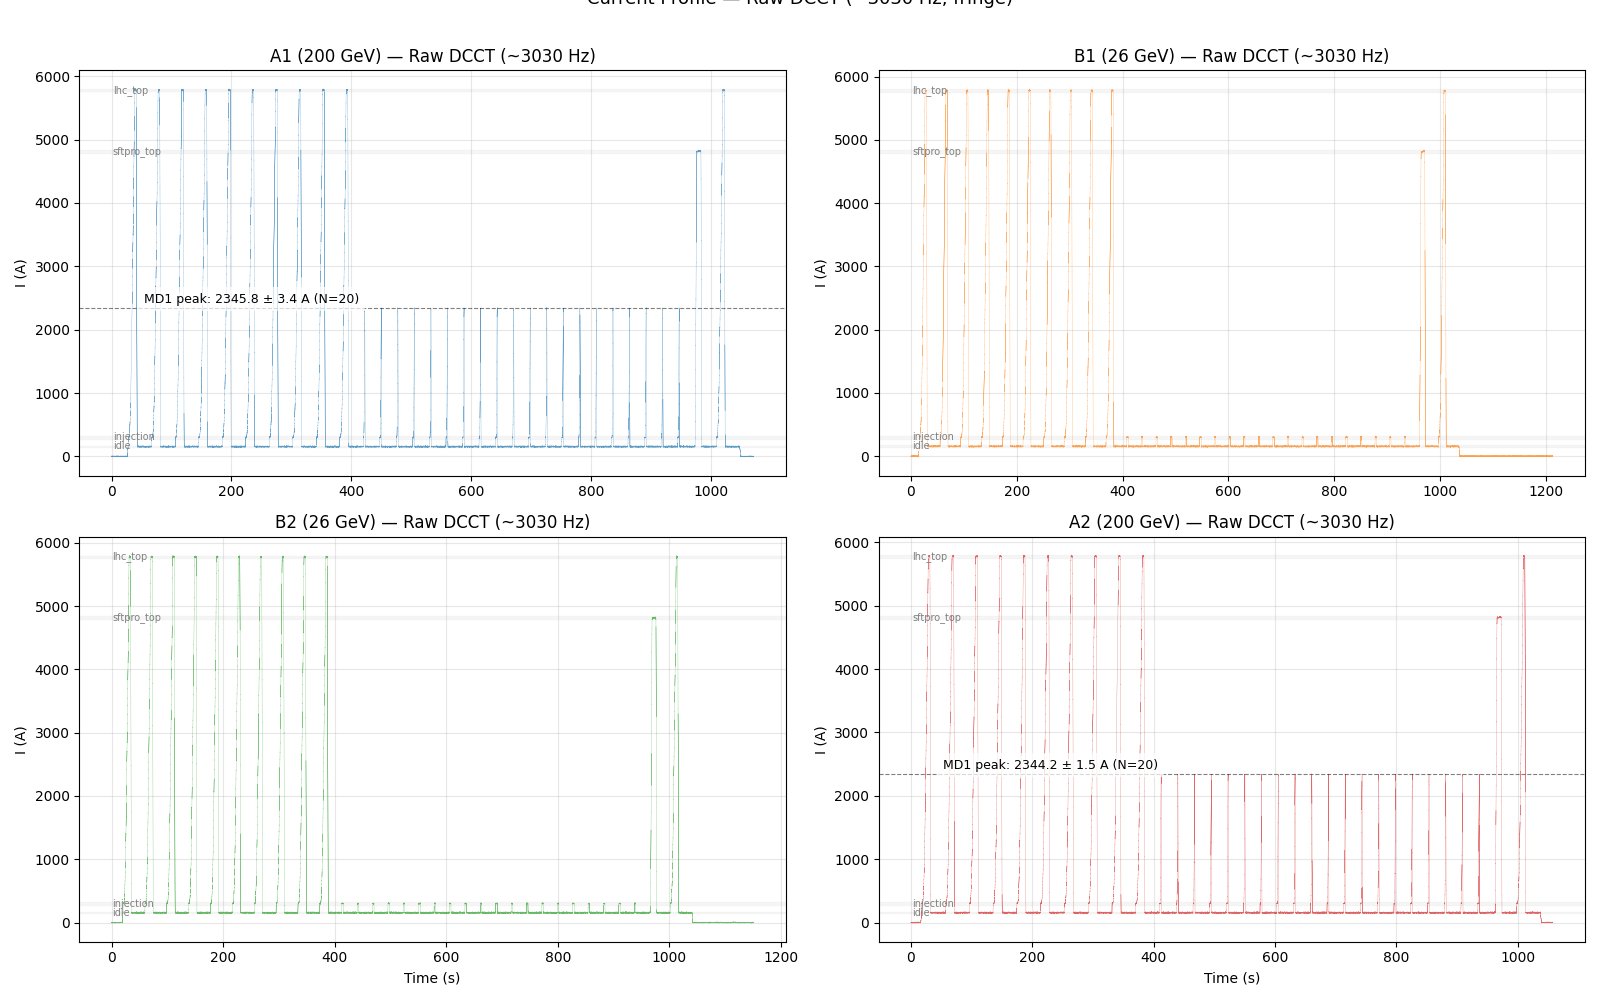

200 GeV MD1 — Instantaneous DCCT Peak Verification
  A1 (200 GeV): 20 cycles, peak = 2345.8 ± 3.4 A, range = 2343.1–2355.8 A
  A2 (200 GeV): 20 cycles, peak = 2344.2 ± 1.5 A, range = 2342.9–2349.4 A


In [3]:
# --- Raw DCCT current at full resolution (~3030 Hz) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
axes = axes.ravel()

md1_peaks = {}

for ax, name in zip(axes, SESSION_NAMES):
    fpath = MEAS / SESSIONS[name]["raw_fringe"]
    raw = np.loadtxt(fpath, usecols=[0, 3])
    t_raw, I_raw = raw[:, 0], raw[:, 1]

    ax.plot(t_raw, I_raw, "-", linewidth=0.2, color=COLORS[name], alpha=0.7)
    ax.set_ylabel("I (A)")
    ax.set_title(f"{name} \u2014 Raw DCCT (~3030 Hz)")

    # Extract MD1 instantaneous peaks for 200 GeV sessions
    if "200 GeV" in name:
        above = I_raw > 1000
        peaks = []
        in_peak = False
        seg_max = 0.0
        for j in range(len(above)):
            if above[j]:
                if not in_peak:
                    in_peak = True
                    seg_max = I_raw[j]
                else:
                    if I_raw[j] > seg_max:
                        seg_max = I_raw[j]
            else:
                if in_peak:
                    if 2000 < seg_max < 3000:
                        peaks.append(seg_max)
                    in_peak = False
        if in_peak and 2000 < seg_max < 3000:
            peaks.append(seg_max)

        md1_peaks[name] = np.array(peaks)
        ax.axhline(np.mean(peaks), color="black", ls="--", lw=0.8, alpha=0.5)
        ax.text(t_raw[len(t_raw) // 20], np.mean(peaks) + 80,
                f"MD1 peak: {np.mean(peaks):.1f} \u00b1 {np.std(peaks):.1f} A "
                f"(N={len(peaks)})", fontsize=9, color="black",
                bbox=dict(fc="white", ec="none", alpha=0.7))

    for bname, (lo, hi) in I_BANDS.items():
        ax.axhspan(lo, hi, alpha=0.06, color="grey")
        ax.text(t_raw[0] + 2, (lo + hi) / 2, bname, fontsize=7,
                va="center", color="grey")

axes[2].set_xlabel("Time (s)")
axes[3].set_xlabel("Time (s)")
fig.suptitle("Current Profile \u2014 Raw DCCT (~3030 Hz, fringe)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- MD1 peak consistency report ---
print("200 GeV MD1 \u2014 Instantaneous DCCT Peak Verification")
print("=" * 65)
for name in ["A1 (200 GeV)", "A2 (200 GeV)"]:
    if name in md1_peaks:
        p = md1_peaks[name]
        print(f"  {name}: {len(p)} cycles, peak = {p.mean():.1f} \u00b1 {p.std():.1f} A, "
              f"range = {p.min():.1f}\u2013{p.max():.1f} A")

---
## 4. Plateau Detection & Phase Classification

Three phases per session:
1. **Standardization (STD):** cycles reaching LHC top (~5781 A) to wipe memory
2. **MD1 conditioning:** cycles reaching injection (~301 A) or ~1300 A, with extended idle (~72 turns)
3. **Measurement (MEAS):** post-MD1 idle, SFTPRO flat top, idle, LHC cycle, post-LHC idle

In [ ]:
def classify_and_group(df, min_consecutive=3):
    """Classify turns into current bands (plateau only if |rr| < threshold)."""
    I = df["I_A"].values
    rr = df["rr"].values
    on_plateau = np.abs(rr) < RAMPRATE_THRESHOLD
    band = np.full(len(I), "", dtype=object)
    for bname, (lo, hi) in I_BANDS.items():
        mask = (I >= lo) & (I <= hi) & on_plateau
        band[mask] = bname

    groups = []
    i = 0
    while i < len(I):
        if band[i] != "":
            label = band[i]
            start = i
            while i < len(I) and band[i] == label:
                i += 1
            if i - start >= min_consecutive:
                groups.append({
                    "label": label, "start": start, "end": i,
                    "n_turns": i - start,
                    "I_mean": I[start:i].mean(),
                    "t_start": df["t_s"].iloc[start],
                    "t_end": df["t_s"].iloc[i - 1],
                })
        else:
            i += 1
    return groups


def assign_phases(groups):
    """Assign phase: 'std', 'md1', or 'meas' to each group.

    Measurement starts at the idle after the last MD1 cycle
    (i.e. the idle between MD1 and SFTPRO).
    """
    # Find the SFTPRO group
    sft = next((g for g in groups if g["label"] == "sftpro_top"), None)
    t_sft = sft["t_start"] if sft else 1e9

    # LHC top groups before SFTPRO = standardization cycles
    std_lhc = [g for g in groups if g["label"] == "lhc_top" and g["t_start"] < t_sft]
    t_end_std = max(g["t_end"] for g in std_lhc) if std_lhc else 0

    # LHC top group after SFTPRO = measurement LHC
    meas_lhc = next((g for g in groups if g["label"] == "lhc_top" and g["t_start"] > t_sft), None)
    t_meas_lhc = meas_lhc["t_start"] if meas_lhc else 1e9

    # End of last active MD1 cycle (last non-idle group before SFTPRO)
    md1_active = [g for g in groups if g["label"] != "idle"
                  and t_end_std < g["t_start"] < t_sft]
    t_md1_end = md1_active[-1]["t_end"] if md1_active else t_sft

    std_idle_idx = 0
    md1_idle_idx = 0
    md1_inj_idx = 0

    for g in groups:
        t = g["t_start"]
        lab = g["label"]

        if t <= t_end_std:
            g["phase"] = "std"
            if lab == "idle":
                std_idle_idx += 1
                g["phase_idx"] = std_idle_idx
            elif lab == "lhc_top":
                g["phase_idx"] = std_idle_idx + 1
            else:
                g["phase_idx"] = 0
        elif t < t_md1_end:
            g["phase"] = "md1"
            if lab == "idle":
                md1_idle_idx += 1
                g["phase_idx"] = md1_idle_idx
            elif lab == "injection":
                md1_inj_idx += 1
                g["phase_idx"] = md1_inj_idx
            else:
                g["phase_idx"] = 0
        else:
            g["phase"] = "meas"
            if lab == "sftpro_top":
                g["cycle"] = "SFTPRO"
            elif lab == "lhc_top":
                g["cycle"] = "LHC"
            elif lab == "idle" and t < t_sft:
                g["cycle"] = "post-MD1"
            elif lab == "idle" and t < t_meas_lhc:
                g["cycle"] = "SFTPRO->LHC"
            elif lab == "idle" and t > t_meas_lhc:
                g["cycle"] = "post-LHC"
            elif lab == "injection":
                g["cycle"] = "LHC"
            else:
                g["cycle"] = "transition"
            g["phase_idx"] = 0
    return groups

---
## 5. Turn Classification Map

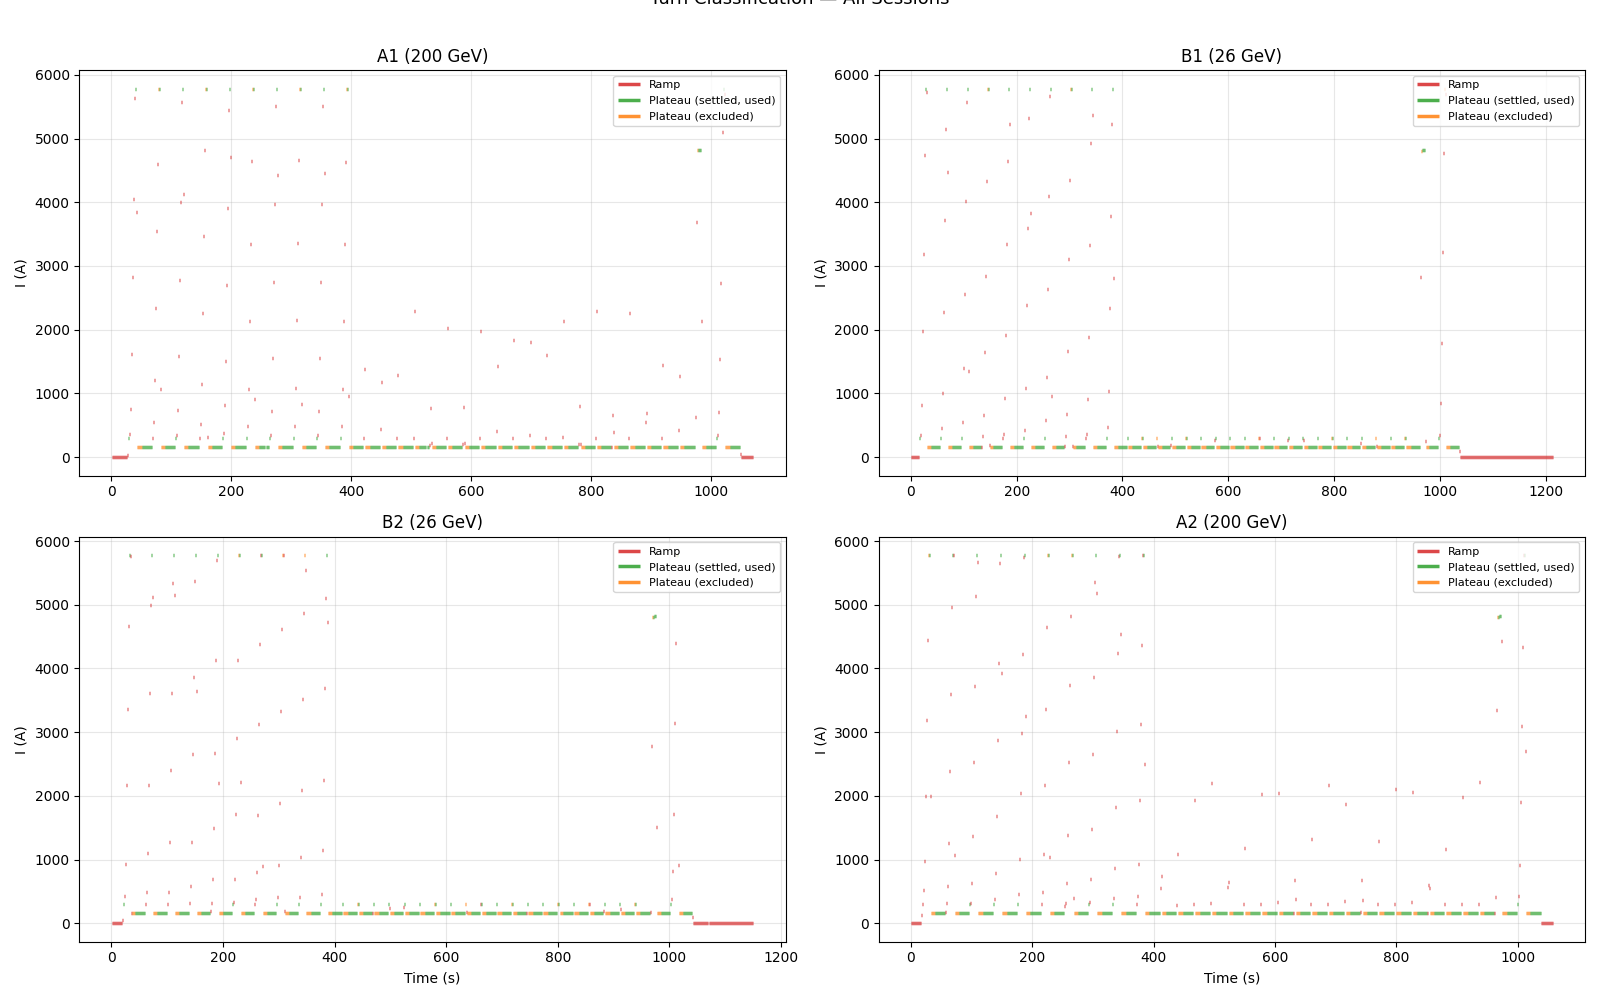

In [5]:
def draw_turn_bars(ax, df, status, idx=None):
    if idx is None:
        idx = range(len(df))
    drawn = set()
    for i in idx:
        s = status[i]
        kw = {}
        if s not in drawn:
            kw["label"] = LABEL_MAP[s]
            drawn.add(s)
        ax.plot([df.t_s.iloc[i], df.t_end.iloc[i]],
                [df.I_A.iloc[i], df.I_A.iloc[i]],
                linewidth=2.5, color=COLOR_MAP[s], alpha=0.85,
                solid_capstyle="butt", zorder=2, **kw)


# Full current profile with turn classification
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()
for ax, name in zip(axes, SESSION_NAMES):
    status = classify_turns(turns[name], all_groups[name])
    draw_turn_bars(ax, turns[name], status)
    ax.set_ylabel("I (A)")
    ax.set_title(f"{name}")
    ax.legend(loc="upper right", fontsize=8)
axes[2].set_xlabel("Time (s)")
axes[3].set_xlabel("Time (s)")
fig.suptitle("Turn Classification \u2014 All Sessions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

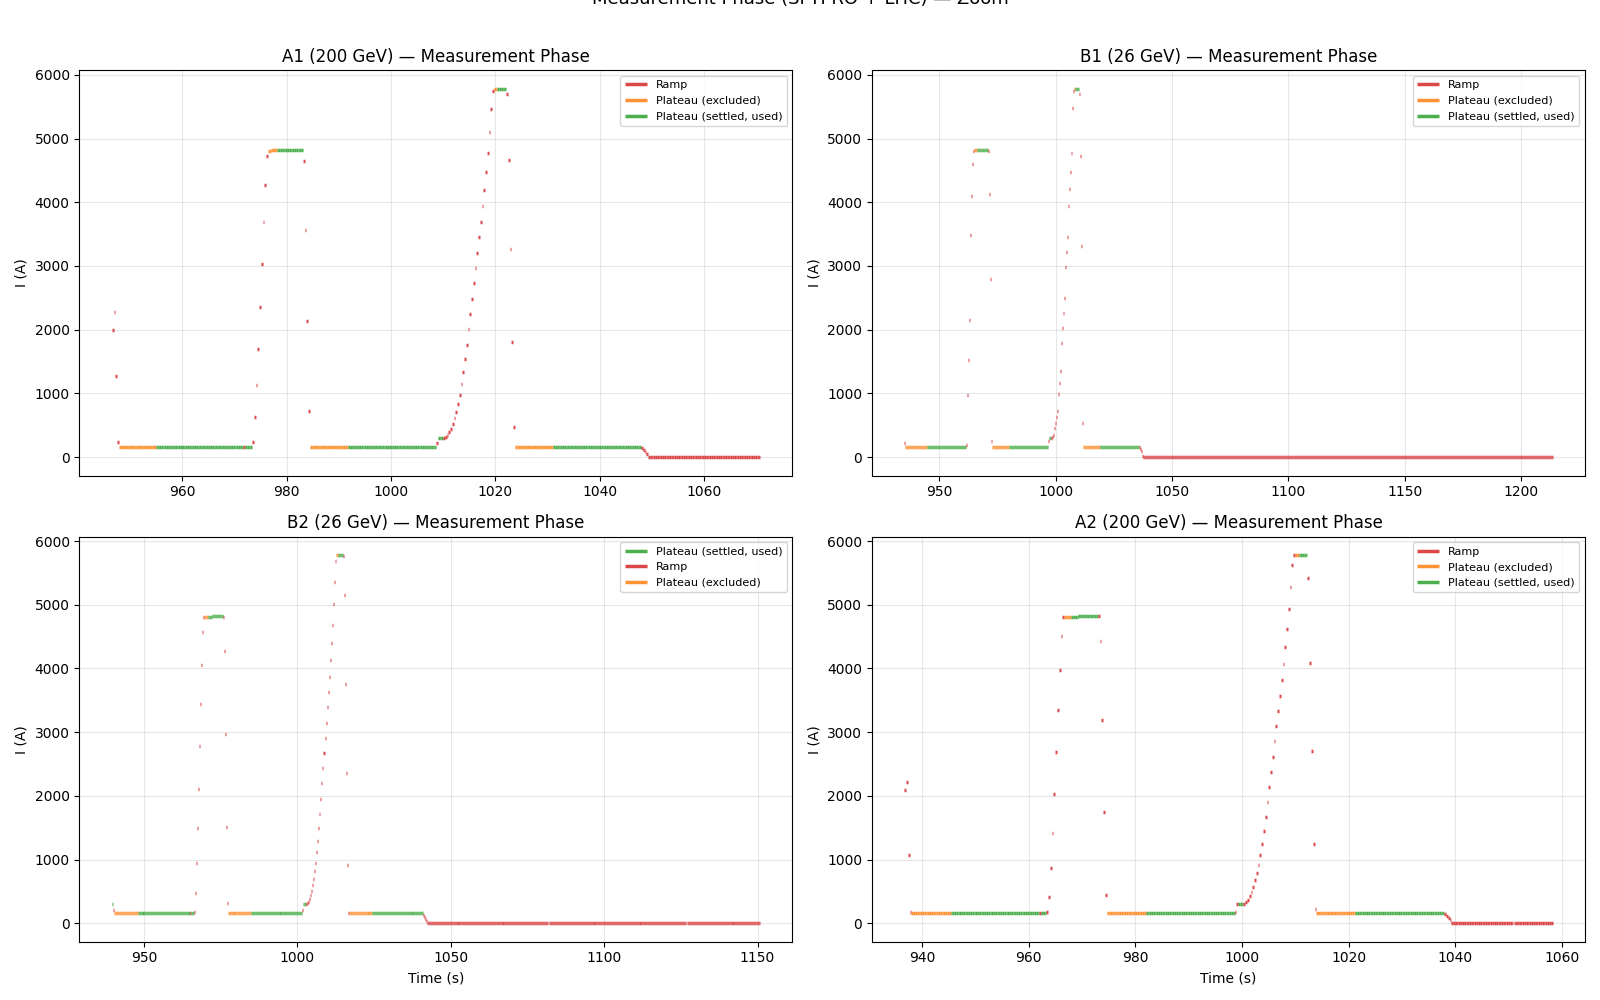

In [6]:
# Zoom on measurement phase (SFTPRO + LHC)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()
for ax, name in zip(axes, SESSION_NAMES):
    df = turns[name]
    grps = all_groups[name]
    status = classify_turns(df, grps)
    meas_grps = [g for g in grps if g["phase"] == "meas"]
    if not meas_grps:
        continue
    t_lo = meas_grps[0]["t_start"] - 30
    idx_zoom = np.where(df.t_s.values >= t_lo)[0]
    draw_turn_bars(ax, df, status, idx_zoom)
    ax.set_ylabel("I (A)")
    ax.set_title(f"{name} \u2014 Measurement Phase")
    ax.legend(loc="upper right", fontsize=8)
axes[2].set_xlabel("Time (s)")
axes[3].set_xlabel("Time (s)")
fig.suptitle("Measurement Phase (SFTPRO + LHC) \u2014 Zoom", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Transfer Function (settled turns)

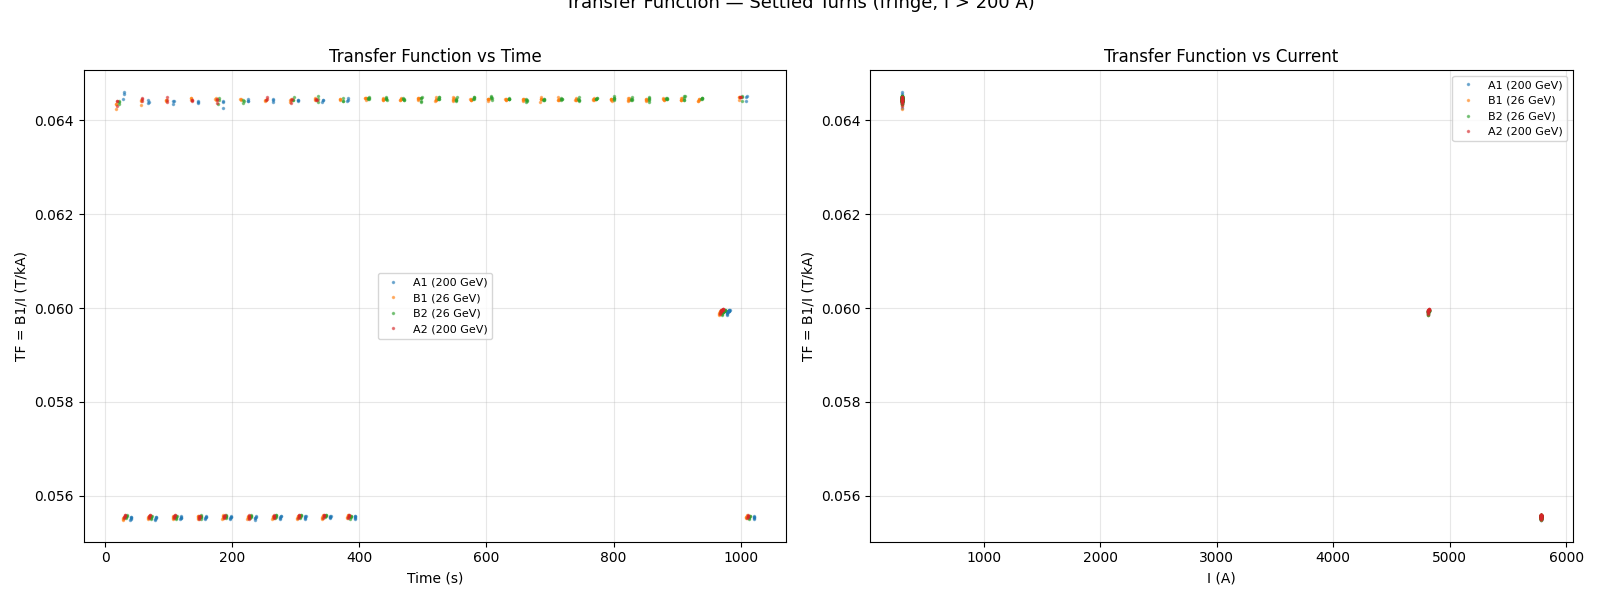

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name in SESSION_NAMES:
    df = turns[name]
    status = classify_turns(df, all_groups[name])
    mask = (status == "settled") & (df.I_A > 200)
    sub = df[mask].copy()
    sub["TF"] = sub.B1_T / sub.I_A * 1000
    axes[0].plot(sub.t_s, sub.TF, ".", ms=3, color=COLORS[name], alpha=0.5, label=name)
    axes[1].plot(sub.I_A, sub.TF, ".", ms=3, color=COLORS[name], alpha=0.5, label=name)

axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("TF = B1/I (T/kA)")
axes[0].set_title("Transfer Function vs Time"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("I (A)"); axes[1].set_ylabel("TF = B1/I (T/kA)")
axes[1].set_title("Transfer Function vs Current"); axes[1].legend(fontsize=8)
fig.suptitle("Transfer Function \u2014 Settled Turns (fringe, I > 200 A)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Standardization Convergence

Track B1 at idle (~155 A) after each of the 10 standardization cycles.
These should converge to the accommodated major loop value.

In [8]:
def settled_stats(df, group, n_settle):
    """Mean and std of settled turns for key quantities."""
    n = min(n_settle, group["n_turns"])
    sl = slice(group["end"] - n, group["end"])
    sub = df.iloc[sl]
    out = {"n_turns": n, "I_mean": sub["I_A"].mean(),
           "I_range": sub["I_A"].max() - sub["I_A"].min()}
    for col in ["B1_T", "b2", "b3"]:
        if col in sub.columns:
            out[f"{col}_mean"] = sub[col].mean()
            out[f"{col}_std"] = sub[col].std()
    return out

---
## 8. MD1 Accommodation at Idle Current

Per-idle-period averages of B1, b2, b3 at ~155 A after each MD1 cycle.
This is the core accommodation analysis: how the remanent state evolves
as MD1 cycles are repeated.

A1 (200 GeV): 22 MD1 idle periods
B1 (26 GeV): 21 MD1 idle periods
B2 (26 GeV): 22 MD1 idle periods
A2 (200 GeV): 22 MD1 idle periods


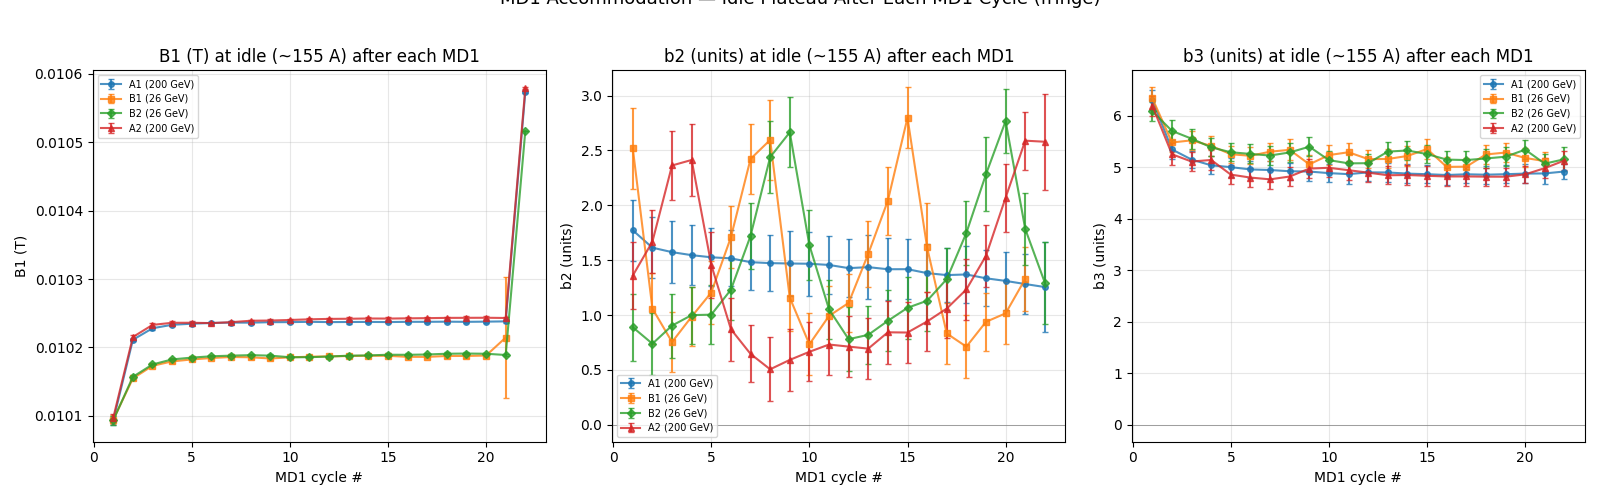

In [9]:
md1_conv = {}
for name in SESSION_NAMES:
    md1_idles = [g for g in all_groups[name]
                 if g["phase"] == "md1" and g["label"] == "idle"]
    rows = []
    for g in md1_idles:
        s = settled_stats(turns[name], g, N_SETTLE["idle"])
        s["cycle"] = g["phase_idx"]
        rows.append(s)
    md1_conv[name] = pd.DataFrame(rows) if rows else pd.DataFrame()
    print(f"{name}: {len(rows)} MD1 idle periods")


# --- Per-cycle B1, b2, b3 ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for col, ylabel, ax in zip(["B1_T", "b2", "b3"],
                            ["B1 (T)", "b2 (units)", "b3 (units)"], axes):
    for name in SESSION_NAMES:
        dc = md1_conv[name]
        if dc.empty:
            continue
        ax.errorbar(dc["cycle"], dc[f"{col}_mean"], yerr=dc[f"{col}_std"],
                    fmt=f"{MARKERS[name]}-", ms=4, capsize=2,
                    color=COLORS[name], alpha=0.8, label=name)
    ax.set_xlabel("MD1 cycle #")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} at idle (~155 A) after each MD1")
    if col != "B1_T":
        ax.axhline(0, color="grey", lw=0.5)
    ax.legend(fontsize=7)

fig.suptitle("MD1 Accommodation \u2014 Idle Plateau After Each MD1 Cycle (fringe)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Convergence quantification: first 3 vs last 3 MD1 idle periods
# Filter out short idle periods (< 20 turns) and slow ramps (I_range > 2 A)
# — the last MD1 idle at ~161 A can be a slow ramp (155→161 A) that passes
# plateau detection but is NOT a true idle.
print("MD1 Accommodation: first 3 vs last 3 idle periods")
print("=" * 90)
for name in SESSION_NAMES:
    dc = md1_conv[name]
    dc = dc[(dc["n_turns"] >= 20) & (dc["I_range"] < 2.0)]
    if dc.empty or len(dc) < 6:
        print(f"  {name}: insufficient data ({len(dc)} periods)")
        continue
    print(f"  {name}:")
    for col, unit in [("B1_T", "T"), ("b2", "units"), ("b3", "units")]:
        first3 = dc[f"{col}_mean"].iloc[:3].mean()
        last3 = dc[f"{col}_mean"].iloc[-3:].mean()
        drift = last3 - first3
        if unit == "T":
            print(f"    {col}: first3={first3:.6f}, last3={last3:.6f}, "
                  f"drift={drift*1e6:+.1f} uT")
        else:
            print(f"    {col}: first3={first3:.4f}, last3={last3:.4f}, "
                  f"drift={drift:+.4f} {unit}")

MD1 Accommodation: first 3 vs last 3 idle periods
  A1 (200 GeV):
    B1_T: first3=0.010178, last3=0.010238, drift=+60.3 uT
    b2: first3=1.6530, last3=1.3096, drift=-0.3434 units
    b3: first3=5.6049, last3=4.8772, drift=-0.7278 units
  B1 (26 GeV):
    B1_T: first3=0.010141, last3=0.010188, drift=+47.0 uT
    b2: first3=1.4437, last3=0.8887, drift=-0.5550 units
    b3: first3=5.7846, last3=5.2416, drift=-0.5430 units
  B2 (26 GeV):
    B1_T: first3=0.010142, last3=0.010190, drift=+48.4 uT
    b2: first3=0.8439, last3=2.2782, drift=+1.4342 units
    b3: first3=5.7863, last3=5.2088, drift=-0.5775 units
  A2 (200 GeV):
    B1_T: first3=0.010182, last3=0.010243, drift=+61.5 uT
    b2: first3=1.7972, last3=2.0659, drift=+0.2687 units
    b3: first3=5.5222, last3=4.8902, drift=-0.6320 units


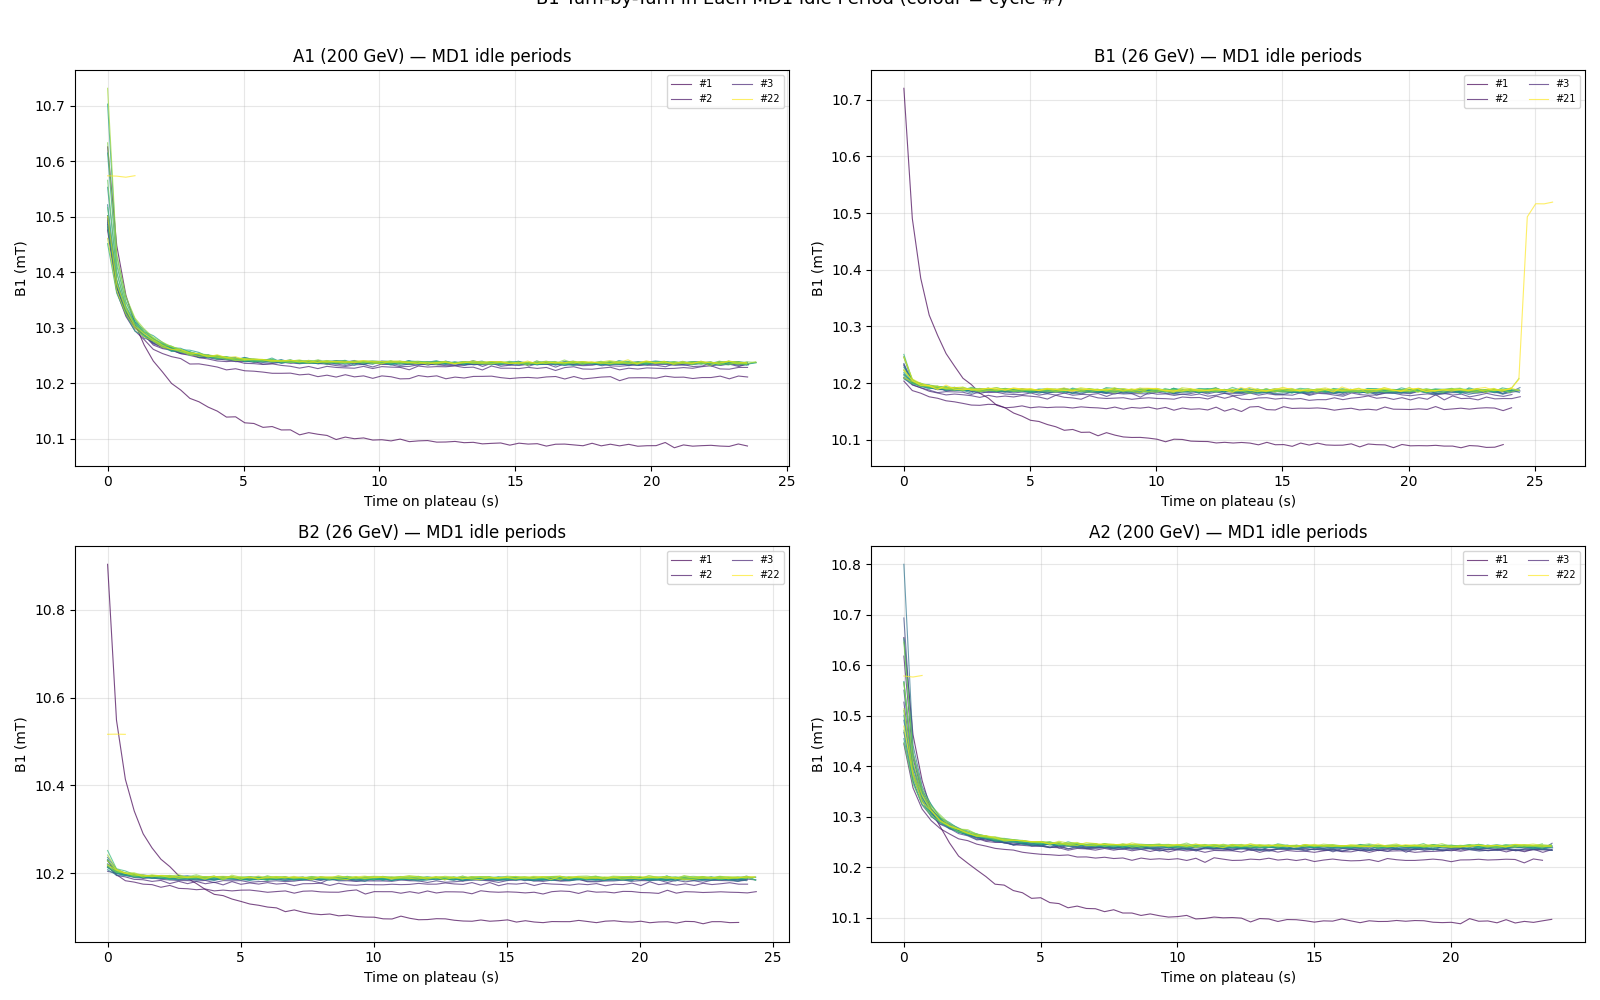

In [11]:
# --- B1 turn-by-turn overlay: all MD1 idle periods stacked ---
# Show the actual settling within each idle period
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, name in zip(axes, SESSION_NAMES):
    md1_idles = [g for g in all_groups[name]
                 if g["phase"] == "md1" and g["label"] == "idle"]
    df = turns[name]
    cmap = plt.cm.viridis(np.linspace(0, 1, max(len(md1_idles), 1)))
    for k, g in enumerate(md1_idles):
        sub = df.iloc[g["start"]:g["end"]]
        local_t = sub.t_s.values - sub.t_s.values[0]
        ax.plot(local_t, sub.B1_T * 1e3, "-", lw=0.8, color=cmap[k],
                alpha=0.7, label=f"#{g['phase_idx']}" if k < 3 or k == len(md1_idles)-1 else None)
    ax.set_xlabel("Time on plateau (s)")
    ax.set_ylabel("B1 (mT)")
    ax.set_title(f"{name} \u2014 MD1 idle periods")
    ax.legend(fontsize=7, ncol=2)

fig.suptitle("B1 Turn-by-Turn in Each MD1 Idle Period (colour = cycle #)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 8b. Eddy Current Settling Analysis

Turn-by-turn settling of B1, b2, b3 on each current plateau.

**Clean plateau turns** (|ramp rate| < 1 A/s) are highlighted with filled markers —
these have current stable throughout the entire rotation period.
Edge turns (within the group but |rr| >= 1 A/s) are shown as faded crosses.

Single-exponential fit: y(t) = y_inf + A * exp(-t / tau)

In [12]:
from scipy.optimize import curve_fit

RR_PLATEAU = 1.0  # A/s — turns below this are "clean plateau"

def eddy_1tau(t, y_inf, A, tau):
    """Single-exponential settling."""
    return y_inf + A * np.exp(-t / tau)

def fit_settling(t, y):
    """Fit 1-tau settling. Returns dict with y_inf, A, tau, R2, ok."""
    t, y = np.asarray(t, float), np.asarray(y, float)
    if len(t) < 5:
        return dict(y_inf=np.nan, A=np.nan, tau=np.nan, R2=np.nan, ok=False)
    y_inf0 = y[-max(3, len(y)//4):].mean()
    A0 = y[0] - y_inf0 or 1e-12
    tau0 = np.clip((t[-1] - t[0]) / 5, 0.3, 50)
    try:
        popt, _ = curve_fit(eddy_1tau, t, y, p0=[y_inf0, A0, tau0],
                            bounds=([-np.inf, -np.inf, 0.05], [np.inf, np.inf, 200]),
                            maxfev=10000)
        resid = y - eddy_1tau(t, *popt)
        ss_tot = np.sum((y - y.mean())**2)
        r2 = 1 - np.sum(resid**2) / ss_tot if ss_tot > 0 else 0
        return dict(y_inf=popt[0], A=popt[1], tau=popt[2], R2=r2, ok=True)
    except Exception:
        return dict(y_inf=np.nan, A=np.nan, tau=np.nan, R2=np.nan, ok=False)


def find_last_clean_md1_idle(groups, df):
    """Last MD1 idle with >= 40 turns and I_range < 3 A (excludes ramp transitions)."""
    idles = [g for g in groups if g["phase"] == "md1" and g["label"] == "idle"
             and g["n_turns"] >= 40]
    for g in reversed(idles):
        sub = df.iloc[g["start"]:g["end"]]
        if sub["I_A"].max() - sub["I_A"].min() < 3.0:
            return g
    return None


EDDY_PLATEAUS_SIMPLE = [
    ("SFTPRO top",       lambda gs: [g for g in gs if g.get("cycle")=="SFTPRO" and g["label"]=="sftpro_top"]),
    ("Post-SFTPRO idle", lambda gs: [g for g in gs if g.get("cycle")=="SFTPRO->LHC" and g["label"]=="idle"]),
    ("LHC top",          lambda gs: [g for g in gs if g.get("cycle")=="LHC" and g["label"]=="lhc_top"]),
    ("Post-LHC idle",    lambda gs: [g for g in gs if g.get("cycle")=="post-LHC" and g["label"]=="idle"]),
]
EDDY_PLAT_NAMES = ["Last clean MD1 idle"] + [p[0] for p in EDDY_PLATEAUS_SIMPLE]

eddy_data = {}
eddy_data["Last clean MD1 idle"] = {}
for name in SESSION_NAMES:
    g = find_last_clean_md1_idle(all_groups[name], turns[name])
    if g is None:
        continue
    sub = turns[name].iloc[g["start"]:g["end"]].copy()
    sub["local_t"] = sub["t_s"].values - sub["t_s"].values[0]
    is_clean = np.abs(sub["rr"].values) < RR_PLATEAU
    clean = sub[is_clean]
    fits = {}
    for col in ["B1_T", "b2", "b3"]:
        fits[col] = fit_settling(clean["local_t"].values, clean[col].values) \
                    if len(clean) >= 5 else dict(ok=False)
    eddy_data["Last clean MD1 idle"][name] = dict(
        sub=sub, clean=clean, is_clean=is_clean, fits=fits,
        cycle_idx=g.get("phase_idx", "?"))

for plat_label, finder in EDDY_PLATEAUS_SIMPLE:
    eddy_data[plat_label] = {}
    for name in SESSION_NAMES:
        matches = finder(all_groups[name])
        if not matches:
            continue
        g = matches[0]
        sub = turns[name].iloc[g["start"]:g["end"]].copy()
        sub["local_t"] = sub["t_s"].values - sub["t_s"].values[0]
        is_clean = np.abs(sub["rr"].values) < RR_PLATEAU
        clean = sub[is_clean]
        fits = {}
        for col in ["B1_T", "b2", "b3"]:
            fits[col] = fit_settling(clean["local_t"].values, clean[col].values) \
                        if len(clean) >= 5 else dict(ok=False)
        eddy_data[plat_label][name] = dict(sub=sub, clean=clean, is_clean=is_clean, fits=fits)

print("Eddy Settling: y(t) = y_inf + A*exp(-t/tau)")
print(f"Clean plateau turns: |rr| < {RR_PLATEAU} A/s")
print("=" * 120)
for plat_label in EDDY_PLAT_NAMES:
    print(f"\n  {plat_label}")
    if "MD1" in plat_label:
        for name in SESSION_NAMES:
            d = eddy_data[plat_label].get(name)
            if d:
                print(f"    {name}: cycle #{d.get('cycle_idx','?')}, "
                      f"{len(d['sub'])} turns, {len(d['clean'])} clean")
    print(f"  {'Session':<16s} {'N':>3s} {'Ncl':>3s}   "
          f"{'B1: A(uT)':>10s} {'tau(s)':>7s} {'R2':>6s}   "
          f"{'b2: A(u)':>9s} {'tau(s)':>7s} {'R2':>6s}   "
          f"{'b3: A(u)':>9s} {'tau(s)':>7s} {'R2':>6s}")
    print("  " + "-" * 108)
    for name in SESSION_NAMES:
        d = eddy_data[plat_label].get(name)
        if d is None:
            continue
        line = f"  {name:<16s} {len(d['sub']):>3d} {len(d['clean']):>3d}   "
        for col, scale, fmt in [("B1_T", 1e6, ".1f"), ("b2", 1, ".3f"), ("b3", 1, ".3f")]:
            f = d["fits"][col]
            if f.get("ok"):
                line += f"{f['A']*scale:>+10{fmt}} {f['tau']:>7.2f} {f['R2']:>6.3f}   "
            else:
                line += f"{'--':>10s} {'--':>7s} {'--':>6s}   "
        print(line)

Eddy Settling: y(t) = y_inf + A*exp(-t/tau)
Clean plateau turns: |rr| < 1.0 A/s

  Last clean MD1 idle
    A1 (200 GeV): cycle #21, 71 turns, 51 clean
    B1 (26 GeV): cycle #20, 74 turns, 45 clean
    B2 (26 GeV): cycle #21, 74 turns, 50 clean
    A2 (200 GeV): cycle #21, 72 turns, 44 clean
  Session            N Ncl    B1: A(uT)  tau(s)     R2    b2: A(u)  tau(s)     R2    b3: A(u)  tau(s)     R2
  ------------------------------------------------------------------------------------------------------------
  A1 (200 GeV)      71  51       +256.5    0.77  0.986       +0.290    0.37  0.020       -4.785    0.67  0.932   
  B1 (26 GeV)       74  45        +56.9    0.35  0.957       +0.145   12.30  0.024       -1.065    0.40  0.474   
  B2 (26 GeV)       74  50        +22.0    1.12  0.699       +7.508  200.00  0.507       +1.211  200.00  0.050   
  A2 (200 GeV)      72  44       +235.6    0.99  0.995       -0.128    6.26  0.016       -4.237    1.10  0.919   

  SFTPRO top
  Session        

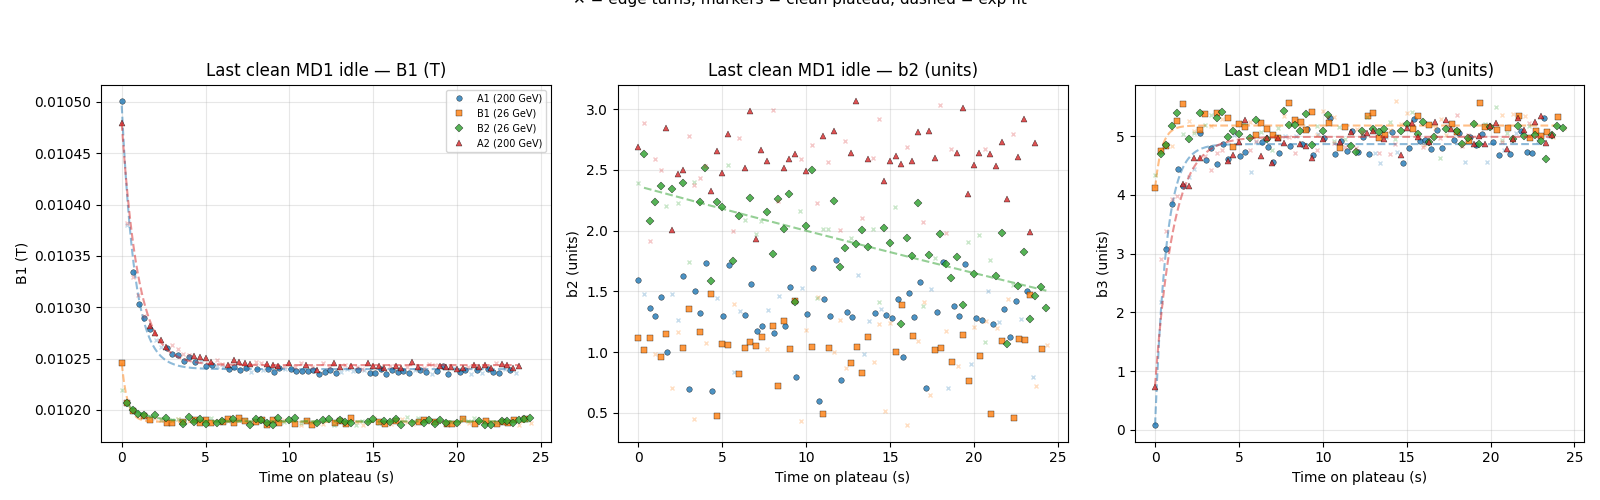

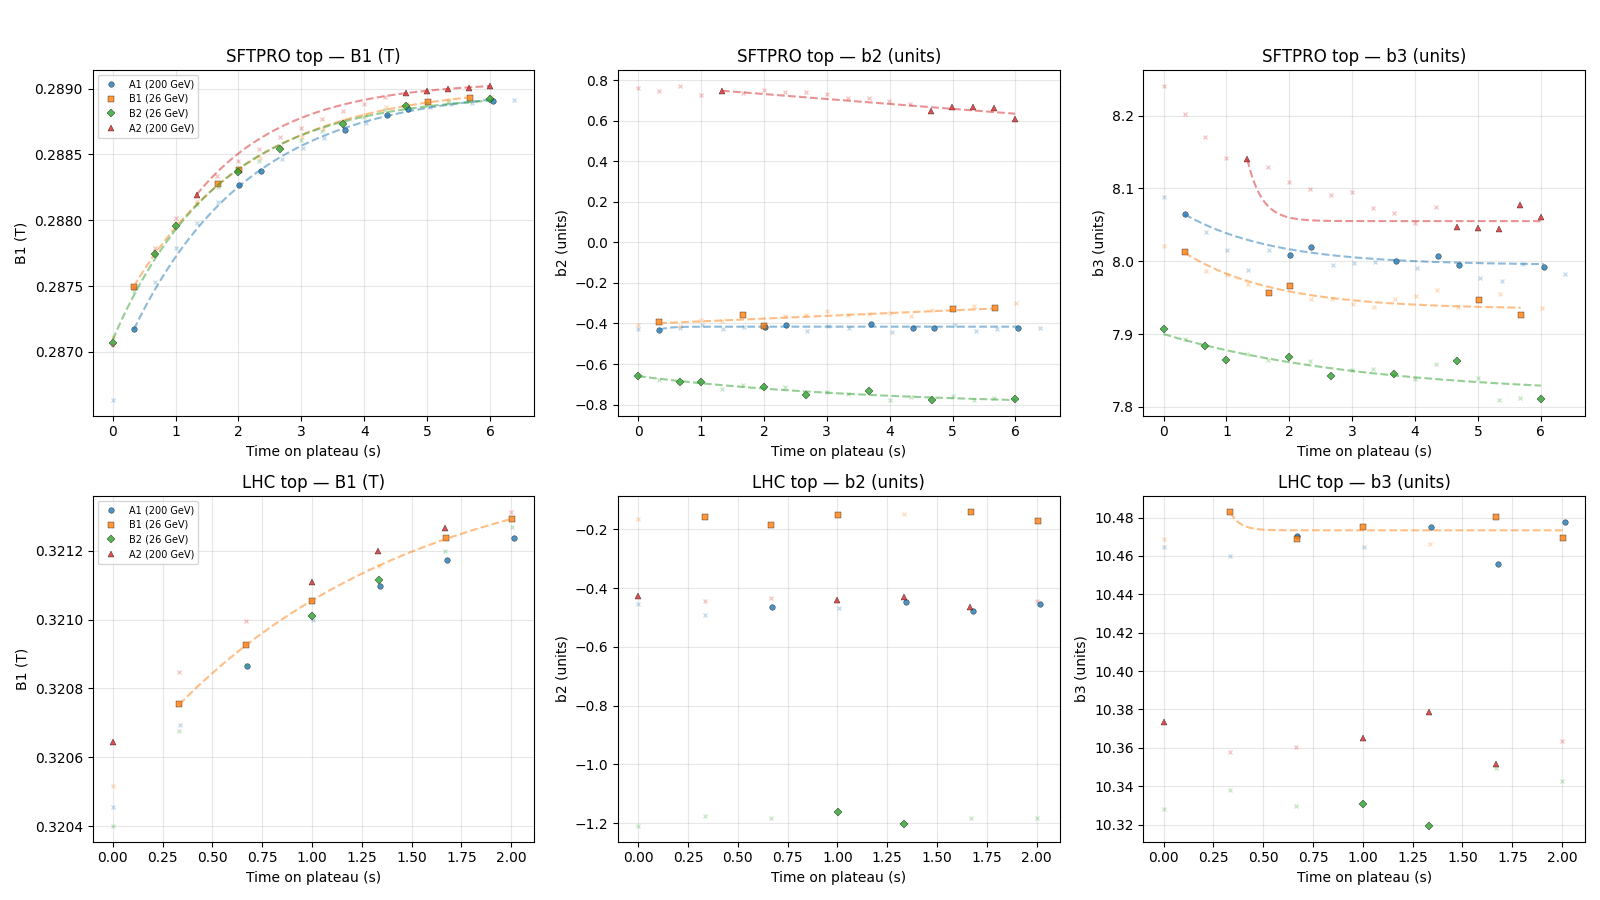

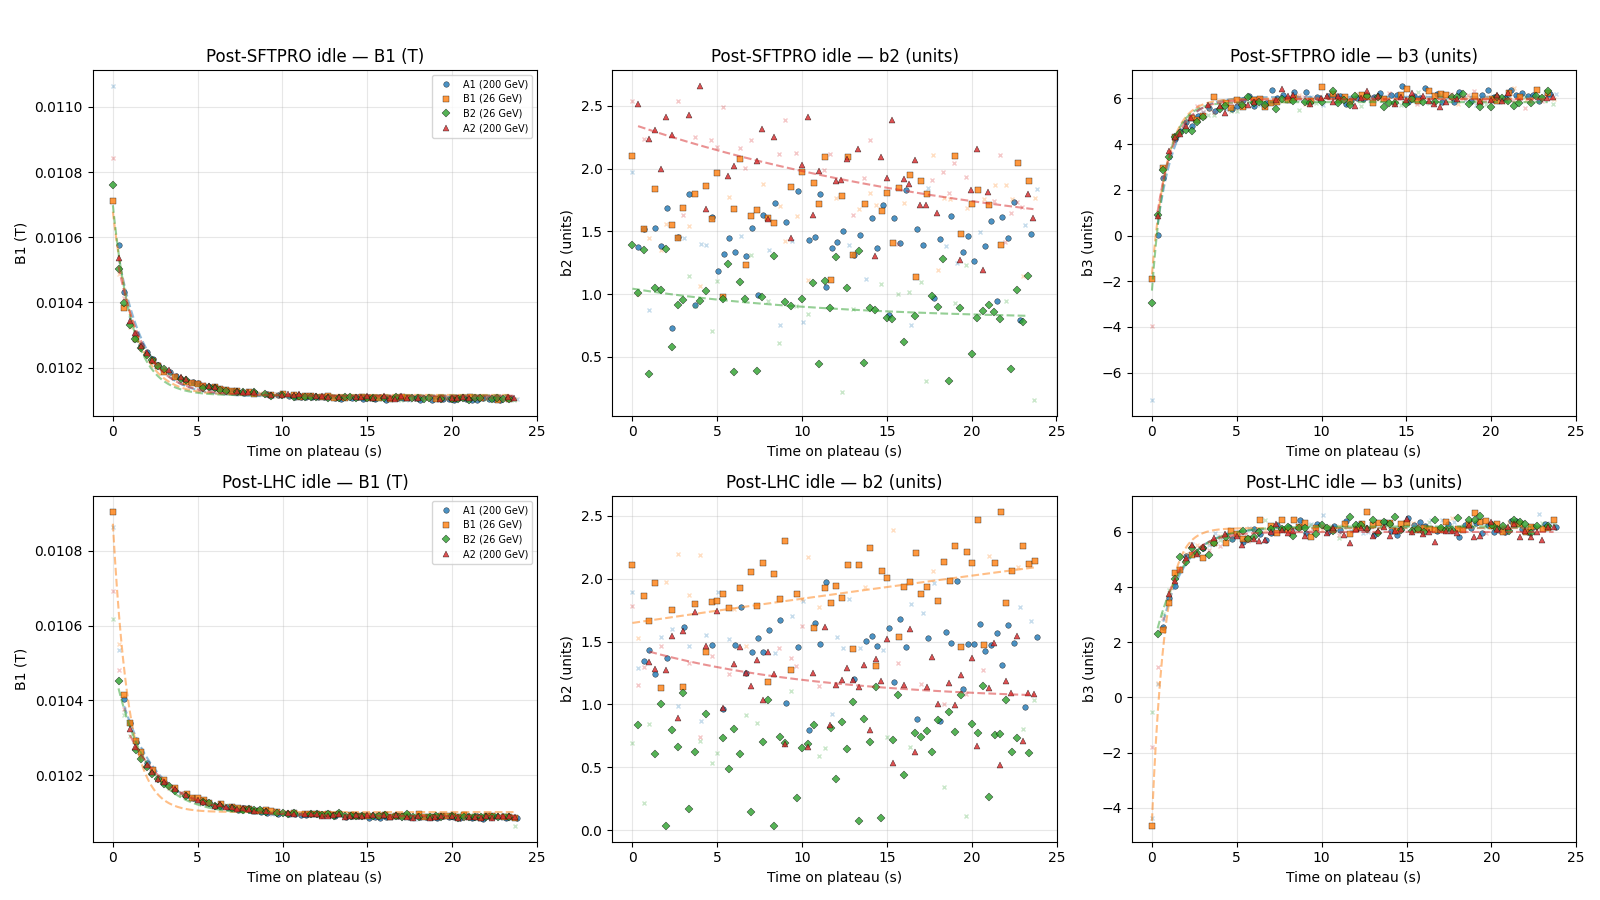

In [13]:
def plot_settling_panel(axes_row, plat_label):
    """Plot B1, b2, b3 settling for one plateau type across all sessions."""
    for ci, (col, ylabel) in enumerate(zip(
        ["B1_T", "b2", "b3"], ["B1 (T)", "b2 (units)", "b3 (units)"]
    )):
        ax = axes_row[ci]
        for name in SESSION_NAMES:
            d = eddy_data[plat_label].get(name)
            if d is None:
                continue
            sub, clean, is_clean = d["sub"], d["clean"], d["is_clean"]
            edge = sub[~is_clean]
            if len(edge):
                ax.plot(edge["local_t"], edge[col], "x", ms=3,
                        alpha=0.25, color=COLORS[name])
            ax.plot(clean["local_t"], clean[col],
                    MARKERS[name], ms=4, color=COLORS[name],
                    alpha=0.8, label=name, markeredgewidth=0.3,
                    markeredgecolor="black")
            f = d["fits"][col]
            if f.get("ok") and f["R2"] > 0.05:
                t_fit = np.linspace(clean["local_t"].min(),
                                    clean["local_t"].max(), 200)
                ax.plot(t_fit, eddy_1tau(t_fit, f["y_inf"], f["A"], f["tau"]),
                        "--", color=COLORS[name], alpha=0.5, lw=1.5)
        ax.set_xlabel("Time on plateau (s)")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{plat_label} \u2014 {ylabel}")
        if ci == 0:
            ax.legend(fontsize=7)


# --- Figure 1: Last clean MD1 idle ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_settling_panel(axes, "Last clean MD1 idle")
fig.suptitle("Eddy Settling: Last Clean MD1 Idle (fringe)\n"
             "\u2715 = edge turns, markers = clean plateau, dashed = exp fit",
             fontsize=11, y=1.05)
plt.tight_layout()
plt.show()

# --- Figure 2: SFTPRO + LHC top ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_settling_panel(axes[0], "SFTPRO top")
plot_settling_panel(axes[1], "LHC top")
fig.suptitle("Eddy Settling: SFTPRO & LHC Top Plateaus (fringe)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# --- Figure 3: Post-SFTPRO + Post-LHC idle ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_settling_panel(axes[0], "Post-SFTPRO idle")
plot_settling_panel(axes[1], "Post-LHC idle")
fig.suptitle("Eddy Settling: Post-SFTPRO & Post-LHC Idle (fringe)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. SFTPRO Flat Top Comparison

Compare B1, b2, b3 at SFTPRO (~4816 A) across all 4 sessions.

=== SFTPRO Top (~4816 A) ===
  A1 (200 GeV): 20 total, 15 settled, I=4817.2 A, B1=0.288663 ± 0.000252 T, b2=-0.421, b3=7.997
  B1 (26 GeV): 19 total, 15 settled, I=4817.1 A, B1=0.288675 ± 0.000257 T, b2=-0.349, b3=7.948
  B2 (26 GeV): 19 total, 15 settled, I=4817.0 A, B1=0.288657 ± 0.000258 T, b2=-0.748, b3=7.846
  A2 (200 GeV): 19 total, 15 settled, I=4817.0 A, B1=0.288750 ± 0.000266 T, b2=0.700, b3=8.080


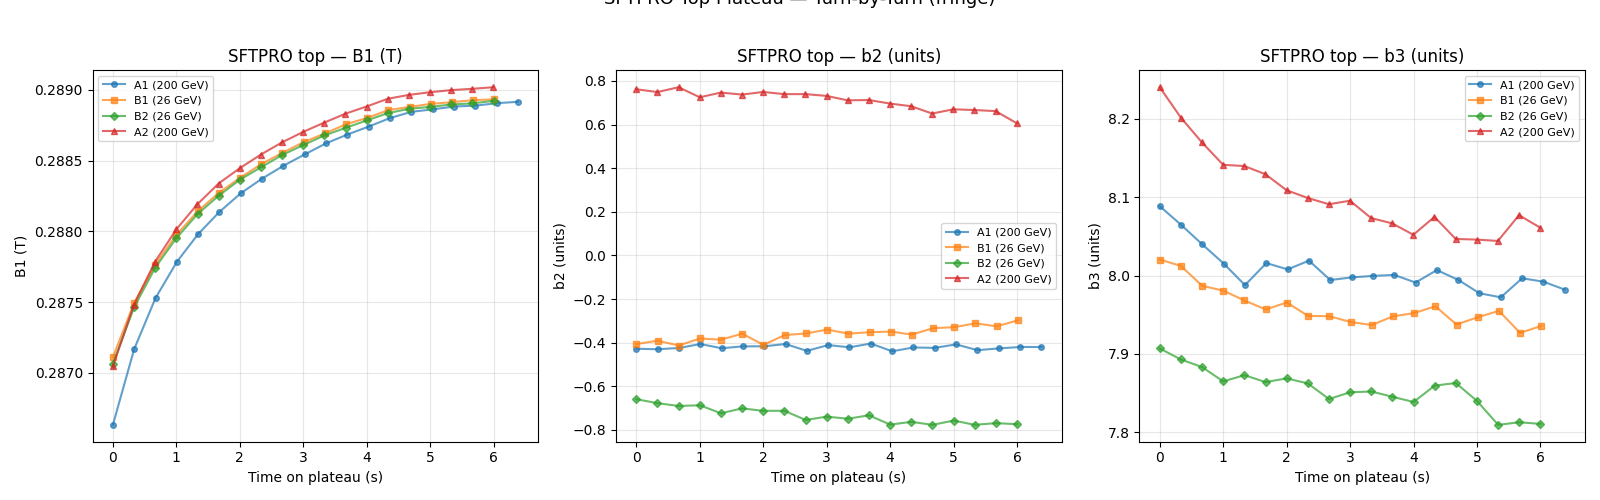

In [14]:
def get_group(groups, phase=None, cycle=None, label=None):
    """Find the first group matching criteria."""
    for g in groups:
        if phase is not None and g.get("phase") != phase:
            continue
        if cycle is not None and g.get("cycle") != cycle:
            continue
        if label is not None and g["label"] != label:
            continue
        return g
    return None


def get_settled_slice(df, group, n_settle):
    n = min(n_settle, group["n_turns"])
    return df.iloc[group["end"] - n : group["end"]]


# SFTPRO comparison
print("=== SFTPRO Top (~4816 A) ===")
sft_stats = {}
for name in SESSION_NAMES:
    g = get_group(all_groups[name], cycle="SFTPRO", label="sftpro_top")
    if g is None:
        print(f"  {name}: SFTPRO not found")
        continue
    sub = get_settled_slice(turns[name], g, N_SETTLE["sftpro_top"])
    sft_stats[name] = sub
    print(f"  {name}: {g['n_turns']} total, {len(sub)} settled, I={sub.I_A.mean():.1f} A, "
          f"B1={sub.B1_T.mean():.6f} \u00b1 {sub.B1_T.std():.6f} T, "
          f"b2={sub.b2.mean():.3f}, b3={sub.b3.mean():.3f}")

# Turn-by-turn overlay
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for col, ylabel, ax in zip(["B1_T", "b2", "b3"],
                            ["B1 (T)", "b2 (units)", "b3 (units)"], axes):
    for name in SESSION_NAMES:
        g = get_group(all_groups[name], cycle="SFTPRO", label="sftpro_top")
        if g is None:
            continue
        sub = turns[name].iloc[g["start"]:g["end"]]
        lt = sub.t_s.values - sub.t_s.values[0]
        ax.plot(lt, sub[col], f"{MARKERS[name]}-", ms=4,
                color=COLORS[name], alpha=0.7, label=name)
    ax.set_xlabel("Time on plateau (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"SFTPRO top \u2014 {ylabel}")
    ax.legend(fontsize=8)

fig.suptitle("SFTPRO Top Plateau \u2014 Turn-by-Turn (fringe)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 10. LHC Flat Top Comparison

=== LHC Top (~5781 A) ===
  A1 (200 GeV): 7 total, 5 settled, I=5780.8 A, B1=0.321075 ± 0.000146 T, b2=-0.462, b3=10.469
  B1 (26 GeV): 7 total, 5 settled, I=5780.7 A, B1=0.321133 ± 0.000146 T, b2=-0.158, b3=10.472
  B2 (26 GeV): 7 total, 5 settled, I=5780.7 A, B1=0.321093 ± 0.000159 T, b2=-1.182, b3=10.334
  A2 (200 GeV): 7 total, 5 settled, I=5780.8 A, B1=0.321177 ± 0.000127 T, b2=-0.443, b3=10.364


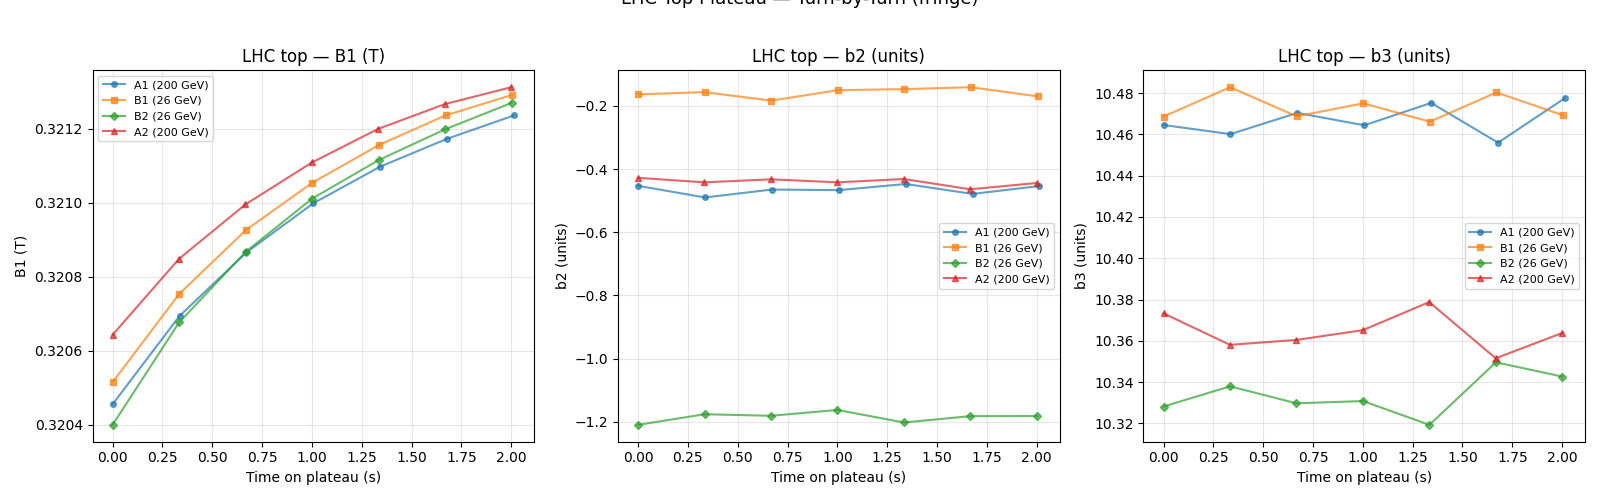

In [15]:
# LHC top comparison
print("=== LHC Top (~5781 A) ===")
lhc_stats = {}
for name in SESSION_NAMES:
    g = get_group(all_groups[name], cycle="LHC", label="lhc_top")
    if g is None:
        print(f"  {name}: LHC top not found")
        continue
    sub = get_settled_slice(turns[name], g, N_SETTLE["lhc_top"])
    lhc_stats[name] = sub
    print(f"  {name}: {g['n_turns']} total, {len(sub)} settled, I={sub.I_A.mean():.1f} A, "
          f"B1={sub.B1_T.mean():.6f} \u00b1 {sub.B1_T.std():.6f} T, "
          f"b2={sub.b2.mean():.3f}, b3={sub.b3.mean():.3f}")

# Turn-by-turn overlay
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for col, ylabel, ax in zip(["B1_T", "b2", "b3"],
                            ["B1 (T)", "b2 (units)", "b3 (units)"], axes):
    for name in SESSION_NAMES:
        g = get_group(all_groups[name], cycle="LHC", label="lhc_top")
        if g is None:
            continue
        sub = turns[name].iloc[g["start"]:g["end"]]
        lt = sub.t_s.values - sub.t_s.values[0]
        ax.plot(lt, sub[col], f"{MARKERS[name]}-", ms=4,
                color=COLORS[name], alpha=0.7, label=name)
    ax.set_xlabel("Time on plateau (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"LHC top \u2014 {ylabel}")
    ax.legend(fontsize=8)

fig.suptitle("LHC Top Plateau \u2014 Turn-by-Turn (fringe)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 11. Post-SFTPRO and Post-LHC Idle (Control)


=== Post-SFTPRO idle (~155 A) ===
  A1 (200 GeV): 72 total, 50 settled, B1=0.010108 ± 0.000006 T, b2=1.396, b3=6.074
  B1 (26 GeV): 72 total, 50 settled, B1=0.010110 ± 0.000006 T, b2=1.703, b3=6.045
  B2 (26 GeV): 72 total, 50 settled, B1=0.010109 ± 0.000006 T, b2=0.852, b3=5.894
  A2 (200 GeV): 72 total, 50 settled, B1=0.010112 ± 0.000006 T, b2=1.880, b3=5.995

=== Post-LHC idle (~155 A, control) ===
  A1 (200 GeV): 72 total, 50 settled, B1=0.010092 ± 0.000006 T, b2=1.483, b3=6.201
  B1 (26 GeV): 72 total, 50 settled, B1=0.010094 ± 0.000007 T, b2=1.953, b3=6.217
  B2 (26 GeV): 72 total, 50 settled, B1=0.010094 ± 0.000008 T, b2=0.712, b3=6.211
  A2 (200 GeV): 72 total, 50 settled, B1=0.010094 ± 0.000007 T, b2=1.154, b3=6.036


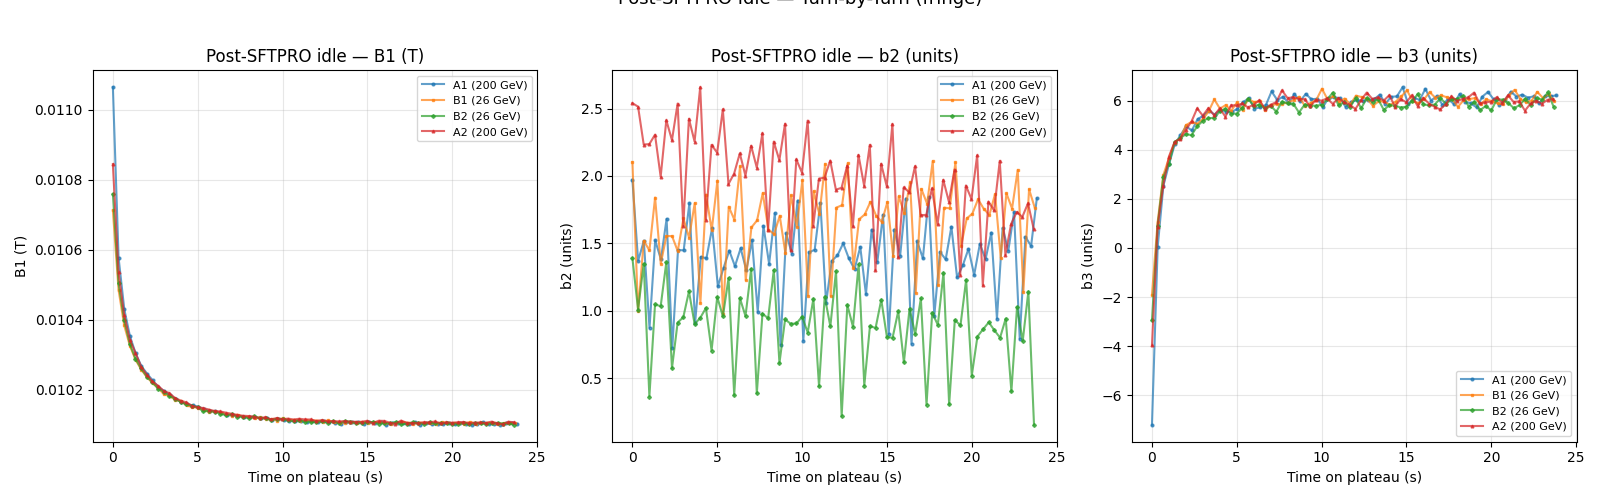

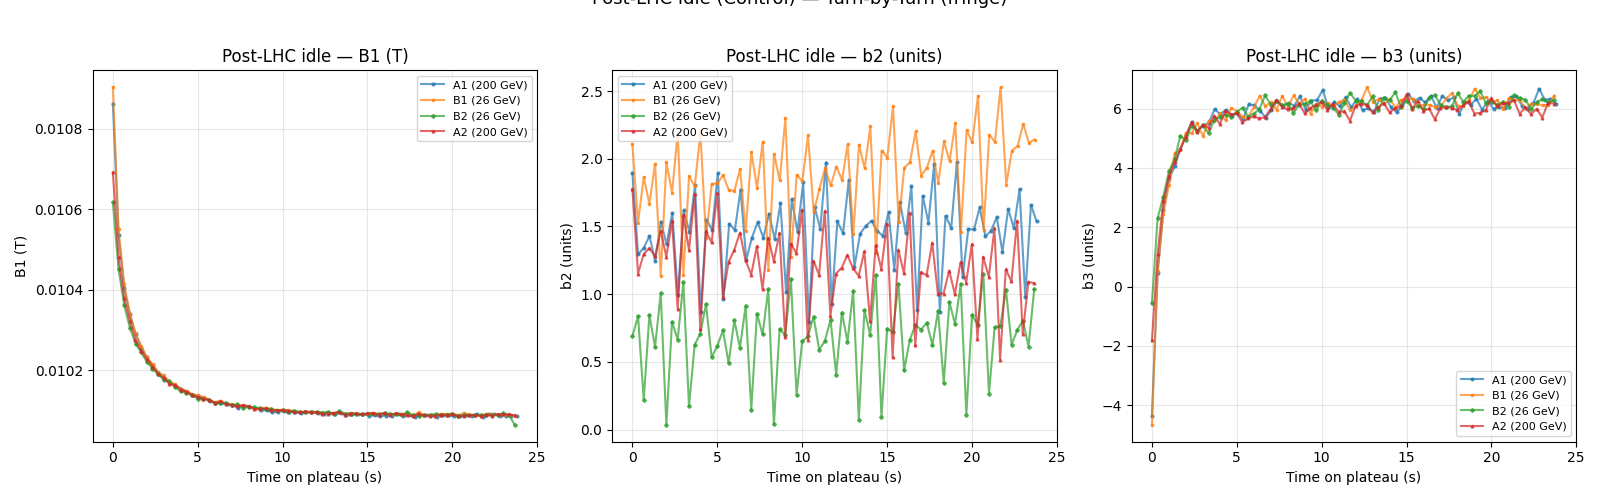

In [16]:
for cycle_label, cycle_name, desc in [
    ("SFTPRO->LHC", "idle", "Post-SFTPRO idle (~155 A)"),
    ("post-LHC", "idle", "Post-LHC idle (~155 A, control)"),
]:
    print(f"\n=== {desc} ===")
    for name in SESSION_NAMES:
        g = get_group(all_groups[name], cycle=cycle_label, label=cycle_name)
        if g is None:
            print(f"  {name}: not found")
            continue
        sub = get_settled_slice(turns[name], g, N_SETTLE["idle"])
        print(f"  {name}: {g['n_turns']} total, {len(sub)} settled, "
              f"B1={sub.B1_T.mean():.6f} \u00b1 {sub.B1_T.std():.6f} T, "
              f"b2={sub.b2.mean():.3f}, b3={sub.b3.mean():.3f}")

# Turn-by-turn: post-SFTPRO idle
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for col, ylabel, ax in zip(["B1_T", "b2", "b3"],
                            ["B1 (T)", "b2 (units)", "b3 (units)"], axes):
    for name in SESSION_NAMES:
        g = get_group(all_groups[name], cycle="SFTPRO->LHC", label="idle")
        if g is None:
            continue
        sub = turns[name].iloc[g["start"]:g["end"]]
        lt = sub.t_s.values - sub.t_s.values[0]
        ax.plot(lt, sub[col], f"{MARKERS[name]}-", ms=2,
                color=COLORS[name], alpha=0.7, label=name)
    ax.set_xlabel("Time on plateau (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Post-SFTPRO idle \u2014 {ylabel}")
    ax.legend(fontsize=8)
fig.suptitle("Post-SFTPRO Idle \u2014 Turn-by-Turn (fringe)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Turn-by-turn: post-LHC idle (control)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for col, ylabel, ax in zip(["B1_T", "b2", "b3"],
                            ["B1 (T)", "b2 (units)", "b3 (units)"], axes):
    for name in SESSION_NAMES:
        g = get_group(all_groups[name], cycle="post-LHC", label="idle")
        if g is None:
            continue
        sub = turns[name].iloc[g["start"]:g["end"]]
        lt = sub.t_s.values - sub.t_s.values[0]
        ax.plot(lt, sub[col], f"{MARKERS[name]}-", ms=2,
                color=COLORS[name], alpha=0.7, label=name)
    ax.set_xlabel("Time on plateau (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Post-LHC idle \u2014 {ylabel}")
    ax.legend(fontsize=8)
fig.suptitle("Post-LHC Idle (Control) \u2014 Turn-by-Turn (fringe)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 12. A-B-B-A Reproducibility

**Same MD1 type should give same result regardless of session order:**
- A1 vs A2 (both 200 GeV): test reproducibility after standardization
- B1 vs B2 (both 26 GeV): test reproducibility after standardization

**True hysteresis (MD1 effect):**
- Average(A1,A2) vs Average(B1,B2): isolates MD1 conditioning effect

In [17]:
def find_last_md1_idle(groups, df, min_turns=40, max_I_range=2.0):
    """Find the last MD1 idle group with sufficient turns and stable current."""
    n_settle = N_SETTLE.get("idle", 50)
    idles = [g for g in groups
             if g.get("phase") == "md1" and g["label"] == "idle"
             and g["n_turns"] >= min_turns]
    for g in reversed(idles):
        n = min(n_settle, g["n_turns"])
        sub = df.iloc[g["end"] - n : g["end"]]
        if sub["I_A"].max() - sub["I_A"].min() < max_I_range:
            return g
    return None


def clean_outliers(sub, k_mad=3.5, trim_edges=2):
    """Reject outlier turns using MAD-based clipping + edge trimming.

    Parameters
    ----------
    k_mad : float
        Multiplier on MAD for B1 and I clipping. 3.5 ≈ 2.4σ for Gaussian.
    trim_edges : int
        Drop this many turns from start and end of the slice (catches ramp edges).
    """
    if len(sub) < 2 * trim_edges + 5:
        return sub
    # Edge trimming: drop first/last turns that may catch ramp
    sub = sub.iloc[trim_edges : len(sub) - trim_edges]
    # B1 clipping
    med_B1 = sub["B1_T"].median()
    mad_B1 = (sub["B1_T"] - med_B1).abs().median()
    if mad_B1 > 0:
        mask_B1 = (sub["B1_T"] - med_B1).abs() <= k_mad * mad_B1
    else:
        mask_B1 = True  # all identical → keep all
    # I clipping (catches remaining ramp-edge turns)
    med_I = sub["I_A"].median()
    mad_I = (sub["I_A"] - med_I).abs().median()
    if mad_I > 0:
        mask_I = (sub["I_A"] - med_I).abs() <= k_mad * mad_I
    else:
        mask_I = (sub["I_A"] - med_I).abs() <= 0.5
    mask = mask_B1 & mask_I
    n_rejected = (~mask).sum()
    if n_rejected > 0:
        print(f"    outlier rejection: {n_rejected}/{len(sub)} turns removed "
              f"(B1 MAD={mad_B1*1e6:.1f} µT, I MAD={mad_I:.3f} A)")
    return sub[mask]


MAX_I_RANGE_SETTLED = {
    "idle": 1.0,
    "injection": 1.0,
    "sftpro_top": 3.0,
    "lhc_top": 3.0,
}

PLATEAUS = [
    ("Last MD1 idle",     None,          None),
    ("SFTPRO top",        "SFTPRO",      "sftpro_top"),
    ("Post-SFTPRO idle",  "SFTPRO->LHC", "idle"),
    ("LHC top",           "LHC",          "lhc_top"),
    ("Post-LHC idle",     "post-LHC",     "idle"),
]

plat_vals = {}
plat_stds = {}
plat_ns = {}

for plat_name, cycle, label in PLATEAUS:
    plat_vals[plat_name] = {}
    plat_stds[plat_name] = {}
    plat_ns[plat_name] = {}
    for name in SESSION_NAMES:
        if cycle is None:
            g = find_last_md1_idle(all_groups[name], turns[name])
        else:
            g = get_group(all_groups[name], cycle=cycle, label=label)
        if g is None:
            continue
        n_s = N_SETTLE.get(g["label"], 18)
        sub = get_settled_slice(turns[name], g, n_s)

        I_range = sub["I_A"].max() - sub["I_A"].min()
        max_ir = MAX_I_RANGE_SETTLED.get(g["label"], 2.0)
        if I_range > max_ir:
            print(f"  WARNING: {name} / {plat_name}: I_range={I_range:.2f} A > {max_ir} A — SKIPPED")
            continue

        print(f"  {name} / {plat_name}:", end="")
        sub = clean_outliers(sub)

        plat_vals[plat_name][name] = {c: sub[c].mean() for c in ["B1_T", "b2", "b3"]}
        plat_stds[plat_name][name] = {c: sub[c].std() for c in ["B1_T", "b2", "b3"]}
        plat_ns[plat_name][name] = len(sub)


print("\nA-B-B-A REPRODUCIBILITY CHECK")
print("=" * 90)
pairs = [
    ("A1 (200 GeV)", "A2 (200 GeV)", "200 GeV reproducibility"),
    ("B1 (26 GeV)",  "B2 (26 GeV)",  "26 GeV reproducibility"),
]

for s1, s2, desc in pairs:
    print(f"\n--- {desc}: {s1} vs {s2} ---")
    for plat_name, _, _ in PLATEAUS:
        v1 = plat_vals[plat_name].get(s1)
        v2 = plat_vals[plat_name].get(s2)
        if v1 is None or v2 is None:
            continue
        d_B1 = (v2["B1_T"] - v1["B1_T"]) * 1e6
        d_b2 = v2["b2"] - v1["b2"]
        d_b3 = v2["b3"] - v1["b3"]
        n1 = plat_ns[plat_name][s1]
        n2 = plat_ns[plat_name][s2]
        sem_B1 = np.sqrt(plat_stds[plat_name][s1]["B1_T"]**2/n1 +
                         plat_stds[plat_name][s2]["B1_T"]**2/n2) * 1e6
        sig = abs(d_B1) / sem_B1 if sem_B1 > 0 else 0
        print(f"  {plat_name:20s}  dB1={d_B1:+8.1f} uT  ({sig:.1f}\u03c3)  "
              f"db2={d_b2:+.3f}  db3={d_b3:+.3f}")

  A1 (200 GeV) / Last MD1 idle:    outlier rejection: 1/46 turns removed (B1 MAD=1.3 µT, I MAD=0.056 A)
  B1 (26 GeV) / Last MD1 idle:    outlier rejection: 5/46 turns removed (B1 MAD=1.4 µT, I MAD=0.054 A)
  B2 (26 GeV) / Last MD1 idle:  A2 (200 GeV) / Last MD1 idle:    outlier rejection: 1/46 turns removed (B1 MAD=1.3 µT, I MAD=0.056 A)
  A1 (200 GeV) / Post-SFTPRO idle:    outlier rejection: 6/46 turns removed (B1 MAD=3.2 µT, I MAD=0.056 A)
  B1 (26 GeV) / Post-SFTPRO idle:    outlier rejection: 8/46 turns removed (B1 MAD=1.9 µT, I MAD=0.075 A)
  B2 (26 GeV) / Post-SFTPRO idle:    outlier rejection: 6/46 turns removed (B1 MAD=2.4 µT, I MAD=0.074 A)
  A2 (200 GeV) / Post-SFTPRO idle:    outlier rejection: 6/46 turns removed (B1 MAD=3.4 µT, I MAD=0.051 A)
  A1 (200 GeV) / LHC top:  B1 (26 GeV) / LHC top:  B2 (26 GeV) / LHC top:  A2 (200 GeV) / LHC top:  A1 (200 GeV) / Post-LHC idle:    outlier rejection: 3/46 turns removed (B1 MAD=3.0 µT, I MAD=0.078 A)
  B1 (26 GeV) / Post-LHC idle: 

In [18]:
# --- True hysteresis: average(200 GeV) vs average(26 GeV) ---
print("\nTRUE HYSTERESIS: Average(200 GeV) vs Average(26 GeV)")
print("=" * 90)
print("Delta = mean(B1,B2) [26 GeV] - mean(A1,A2) [200 GeV]")
print()

A_sessions = ["A1 (200 GeV)", "A2 (200 GeV)"]
B_sessions = ["B1 (26 GeV)",  "B2 (26 GeV)"]

summary_rows = []
print(f"{'Plateau':<22s} {'200 GeV B1 (T)':>16s} {'26 GeV B1 (T)':>16s} "
      f"{'Delta B1 (uT)':>14s} {'Delta b2':>10s} {'Delta b3':>10s}")
print("-" * 92)

for plat_name, cycle, label in PLATEAUS:
    vals_A = [plat_vals[plat_name][s] for s in A_sessions if s in plat_vals[plat_name]]
    vals_B = [plat_vals[plat_name][s] for s in B_sessions if s in plat_vals[plat_name]]

    if not vals_A or not vals_B:
        continue

    row = {"Plateau": plat_name}
    for col in ["B1_T", "b2", "b3"]:
        mean_A = np.mean([v[col] for v in vals_A])
        mean_B = np.mean([v[col] for v in vals_B])
        row[f"200GeV_{col}"] = mean_A
        row[f"26GeV_{col}"] = mean_B
        row[f"delta_{col}"] = mean_B - mean_A

    summary_rows.append(row)
    d_B1 = row["delta_B1_T"] * 1e6
    print(f"{plat_name:<22s} {row['200GeV_B1_T']:>16.6f} {row['26GeV_B1_T']:>16.6f} "
          f"{d_B1:>+14.1f} {row['delta_b2']:>+10.3f} {row['delta_b3']:>+10.3f}")


def _get_clean_settled_B1(session_list, cycle, label):
    all_B1 = []
    for s in session_list:
        if cycle is None:
            g = find_last_md1_idle(all_groups[s], turns[s])
        else:
            g = get_group(all_groups[s], cycle=cycle, label=label)
        if g is None: continue
        n_s = N_SETTLE.get(g["label"], 18)
        sub = get_settled_slice(turns[s], g, n_s)
        I_range = sub["I_A"].max() - sub["I_A"].min()
        if I_range > MAX_I_RANGE_SETTLED.get(g["label"], 2.0): continue
        sub = clean_outliers(sub)
        all_B1.extend(sub.B1_T.values)
    return np.array(all_B1)


print("\nStatistical significance (pooled over both sessions):")
for plat_name, cycle, label in PLATEAUS:
    all_A = _get_clean_settled_B1(A_sessions, cycle, label)
    all_B = _get_clean_settled_B1(B_sessions, cycle, label)
    if len(all_A) == 0 or len(all_B) == 0:
        continue
    delta = (all_B.mean() - all_A.mean()) * 1e6
    sem = np.sqrt(all_A.var()/len(all_A) + all_B.var()/len(all_B)) * 1e6
    sig = abs(delta) / sem if sem > 0 else 0
    print(f"  {plat_name:22s}: delta={delta:+.1f} uT, SEM={sem:.1f} uT, "
          f"{sig:.1f}\u03c3 (N_A={len(all_A)}, N_B={len(all_B)})")


TRUE HYSTERESIS: Average(200 GeV) vs Average(26 GeV)
Delta = mean(B1,B2) [26 GeV] - mean(A1,A2) [200 GeV]

Plateau                  200 GeV B1 (T)    26 GeV B1 (T)  Delta B1 (uT)   Delta b2   Delta b3
--------------------------------------------------------------------------------------------
Last MD1 idle                  0.010241         0.010188          -52.1     -0.544     +0.175
Post-SFTPRO idle               0.010108         0.010107           -1.1     -0.355     -0.044
LHC top                        0.321126         0.321113          -12.9     -0.218     -0.013
Post-LHC idle                  0.010091         0.010093           +1.5     +0.032     +0.112

Statistical significance (pooled over both sessions):
    outlier rejection: 1/46 turns removed (B1 MAD=1.3 µT, I MAD=0.056 A)
    outlier rejection: 1/46 turns removed (B1 MAD=1.3 µT, I MAD=0.056 A)
    outlier rejection: 5/46 turns removed (B1 MAD=1.4 µT, I MAD=0.054 A)
  Last MD1 idle         : delta=-52.1 uT, SEM=0.4 uT, 1

---
## 13. Summary Table & Delta Bar Charts

In [19]:
# Full summary table: all 4 sessions x all plateaus
table_rows = []
for plat_name, cycle, label in PLATEAUS:
    for name in SESSION_NAMES:
        v = plat_vals[plat_name].get(name)
        s = plat_stds[plat_name].get(name)
        n = plat_ns[plat_name].get(name, 0)
        if v is None:
            continue
        table_rows.append({
            "Plateau": plat_name, "Session": name, "MD1": SESSIONS[name]["md1"],
            "N": n,
            "B1 (T)": v["B1_T"], "B1 std (T)": s["B1_T"],
            "b2 (units)": v["b2"], "b3 (units)": v["b3"],
        })

df_table = pd.DataFrame(table_rows)
print("Full Summary Table")
print("=" * 100)
display(df_table.round(6))

Full Summary Table


,Plateau,Session,MD1,N,B1 (T),B1 std (T),b2 (units),b3 (units)
0,Last MD1 idle,A1 (200 GeV),200 GeV,45,0.010238,0.000002,1.300808,4.889181
1,Last MD1 idle,B1 (26 GeV),26 GeV,41,0.010188,0.000002,1.022644,5.165423
2,Last MD1 idle,B2 (26 GeV),26 GeV,46,0.010189,0.000002,1.788274,5.064671
3,Last MD1 idle,A2 (200 GeV),200 GeV,45,0.010243,0.000002,2.597680,4.990870
4,Post-SFTPRO idle,A1 (200 GeV),200 GeV,40,0.010106,0.000004,1.405933,6.071419
5,Post-SFTPRO idle,B1 (26 GeV),26 GeV,38,0.010107,0.000003,1.686643,6.052108
6,Post-SFTPRO idle,B2 (26 GeV),26 GeV,40,0.010107,0.000003,0.856633,5.910273
7,Post-SFTPRO idle,A2 (200 GeV),200 GeV,40,0.010110,0.000004,1.847025,5.979275
8,LHC top,A1 (200 GeV),200 GeV,5,0.321075,0.000146,-0.462416,10.468740
9,LHC top,B1 (26 GeV),26 GeV,5,0.321133,0.000146,-0.158425,10.471919


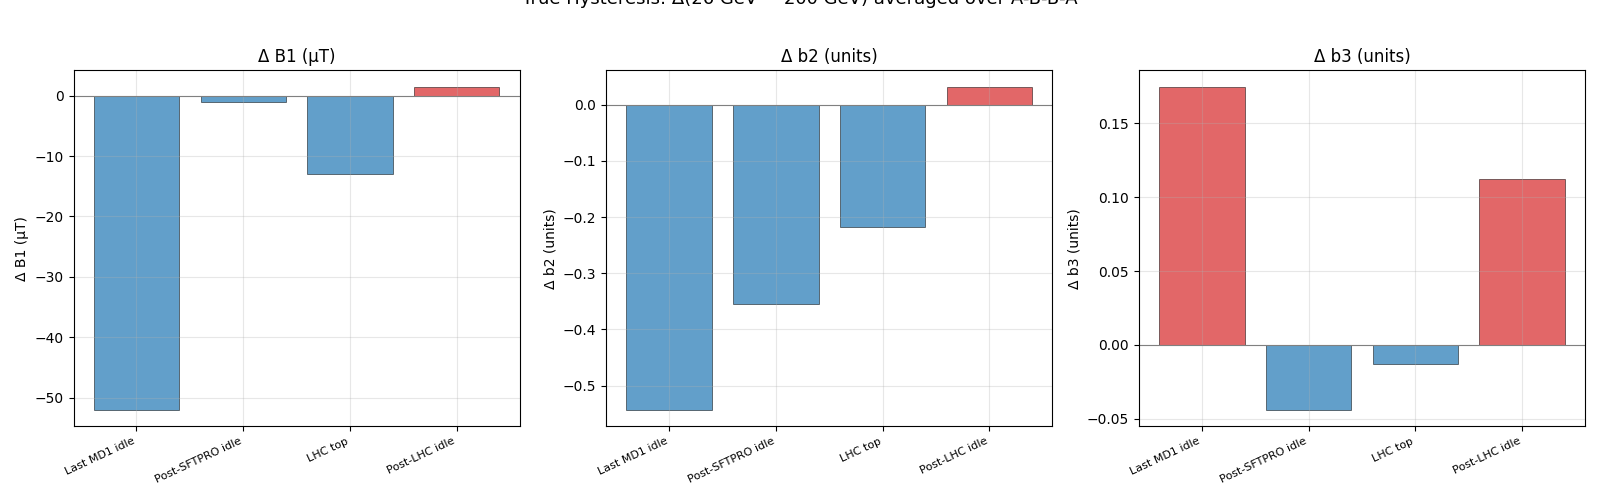

In [20]:
# Delta bar chart: true hysteresis (26 GeV - 200 GeV averaged)
plat_labels = [r["Plateau"] for r in summary_rows]
deltas_B1 = [r["delta_B1_T"] * 1e6 for r in summary_rows]
deltas_b2 = [r["delta_b2"] for r in summary_rows]
deltas_b3 = [r["delta_b3"] for r in summary_rows]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(plat_labels))

for ax, vals, ylabel in zip(axes,
                            [deltas_B1, deltas_b2, deltas_b3],
                            ["\u0394 B1 (\u00b5T)", "\u0394 b2 (units)", "\u0394 b3 (units)"]):
    colors = ["tab:red" if v > 0 else "tab:blue" for v in vals]
    ax.bar(x, vals, color=colors, alpha=0.7, edgecolor="black", lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(plat_labels, rotation=25, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_title(ylabel)

fig.suptitle("True Hysteresis: \u0394(26 GeV \u2212 200 GeV) averaged over A-B-B-A",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

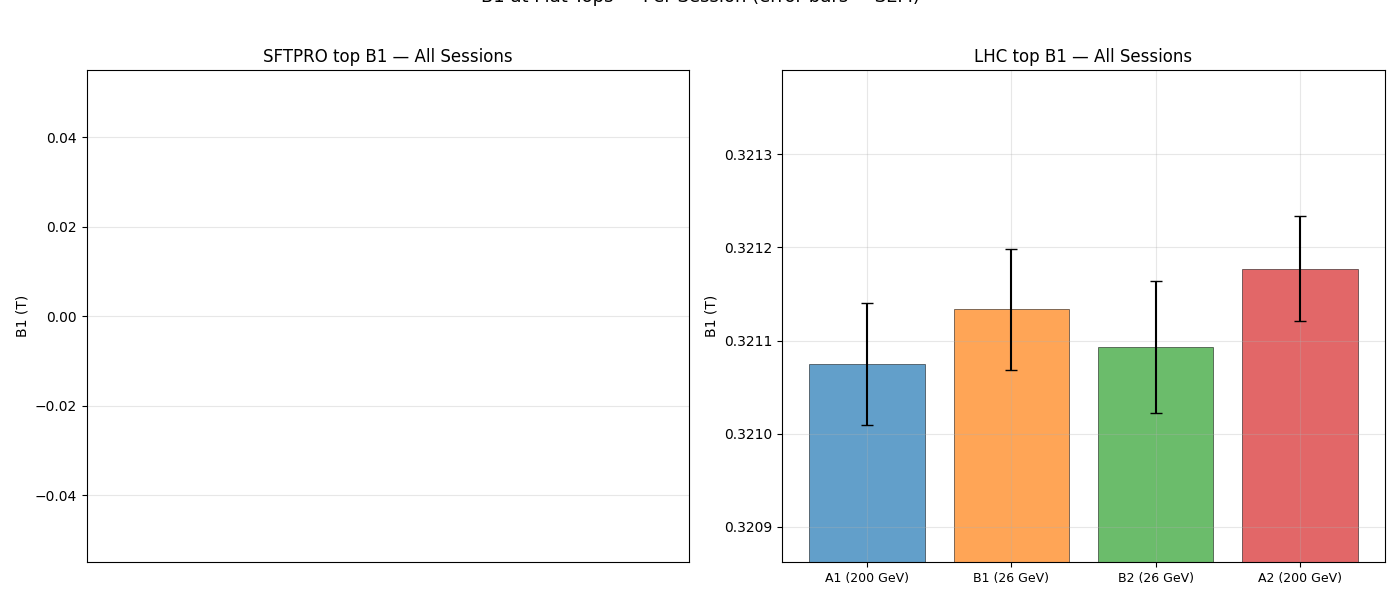

In [21]:
# Per-session bar chart for SFTPRO and LHC top
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (plat_name, cycle, label) in zip(axes, [
    ("SFTPRO top", "SFTPRO", "sftpro_top"),
    ("LHC top",    "LHC",    "lhc_top"),
]):
    session_labels = []
    b1_vals = []
    b1_errs = []
    bar_colors = []
    for name in SESSION_NAMES:
        v = plat_vals[plat_name].get(name)
        s = plat_stds[plat_name].get(name)
        n = plat_ns[plat_name].get(name, 0)
        if v is None:
            continue
        session_labels.append(name)
        b1_vals.append(v["B1_T"])
        b1_errs.append(s["B1_T"] / np.sqrt(n) if n > 1 else 0)
        bar_colors.append(COLORS[name])

    x = np.arange(len(session_labels))
    ax.bar(x, b1_vals, yerr=b1_errs, color=bar_colors, alpha=0.7,
           edgecolor="black", lw=0.5, capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(session_labels, fontsize=9)
    ax.set_ylabel("B1 (T)")
    ax.set_title(f"{plat_name} B1 \u2014 All Sessions")
    # Don't start y-axis at 0 for better visibility of differences
    if b1_vals:
        ymin = min(b1_vals) - 3 * max(b1_errs) if max(b1_errs) > 0 else min(b1_vals) * 0.9999
        ymax = max(b1_vals) + 3 * max(b1_errs) if max(b1_errs) > 0 else max(b1_vals) * 1.0001
        ax.set_ylim(ymin, ymax)

fig.suptitle("B1 at Flat Tops \u2014 Per Session (error bars = SEM)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 14. Interpretation

### A-B-B-A Design Advantages

With proper standardization (10x to 5781 A before each session):

1. **Session-ordering confound eliminated:** A1 and A2 bracket the B sessions.
   If A1 \u2248 A2 and B1 \u2248 B2, ordering doesn't matter.
2. **True MD1 effect isolated:** \u0394 = mean(B1,B2) \u2212 mean(A1,A2) is the genuine
   hysteresis difference due to MD1 conditioning level.
3. **Statistical power doubled:** pooling two sessions per MD1 type gives
   2x the turns for statistics.

### Preisach Prediction

After standardization to 5781 A, both MD1 types add minor loops below 5781 A.
The wiping-out property erases these when the ascending ramp exceeds the
MD1 maximum (2267 A or 301 A). At SFTPRO (4816 A >> 2267 A), both sessions
should be on the same ascending branch \u2192 \u0394 = 0.

A nonzero \u0394 would indicate accommodation, reptation, or other non-Preisach effects.

### Post-LHC Idle as Control

All sessions descend from the same LHC top (5781 A). Post-LHC idle should
give identical B across all 4 sessions. Nonzero \u0394 here indicates incomplete
standardization or systematic errors.

---
## Notes

- **Fringe segment** (`is_fringe=True`).
- **Encoder offset correction** applied: raw `arg(C_1) = −90.4°`, correction equivalent to
  `encoder_offset_rad = −π/2`: B1 flips positive, even-order b_n flip sign.
- Per-turn results use `dri rot nor` pipeline from DAQ software.
- **No NMR** in this campaign. Rotating coil only.
- Settling: idle=50 turns, sftpro=15 turns, lhc=5 turns.
- **Per-turn averaging artifact on 200 GeV MD1:** The per-turn `I(A)` in results files
  averages over ~0.33 s rotation period. The 200 GeV MD1 triangular ramp above 2000 A
  lasts only ~1.2 s (3–4 turns), so per-turn averages vary (2150–2300 A). The
  instantaneous DCCT peaks are perfectly consistent at ~2345 A (std ~3 A, <0.15%).
  See Section 3a for raw DCCT verification.